# Relative Error Decay Comparison Across Tools

This notebook compares the attached decay-study outputs from BioDynaMo, Chaste, CompuTiX, PhysiCell, and TiSim using the relative error against the analytical solution.

The workflow is split into the same steps as the absolute-error notebook:
1. Load the result files into one common table using the whole-box average concentration.
2. Build a dense analytical solution and interpolate it onto each tool's time grid.
3. Compute the relative error for every run and rank the runs within each tool.
4. Keep only the run with the smallest mean relative error for each tool and compare those best runs directly.

In [1]:
from pathlib import Path
from textwrap import fill
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import yaml


## Step 1: Define Study Paths And Shared Physical Parameters

The four tools store their outputs in different formats, but they all represent the same decay setup.
For this comparison we use the average concentration over the full box because it is available for every attached tool result.

In [2]:
ROOT = Path('/home/tntiniak/Work/observatory_benchmark')

BIODYNAMO_DIR = ROOT / 'Biodynamo' / 'diffusion_decay_test'
CHASTE_DIR = ROOT / 'Chaste' / 'DiffusionNoCells'
COMPUTIX_DIR = ROOT / 'CompuTiX' / 'diffusion_single' / 'Decay'
PHYSICELL_DIR = ROOT / 'PhysiCell' / 'results' / 'decay_study'
PHYSICELL_EXPORT_FILENAME = 'physicell_decay_plot_data.csv'
ANALYTICAL_DIR = ROOT / 'analytical_solutions' / 'diffusion' / 'Decay'

## Step 2: Load analytical Solutions


In [3]:
analytical_df = pd.read_csv(
    ANALYTICAL_DIR / 'analytical_values.csv',
    usecols=['time_min', 'center_concentration_uM', 'average_concentration_uM'],
    dtype={
        'time_min': float,
        'center_concentration_uM': float,
        'average_concentration_uM': float,
    },
)
analytical_df['time_min'] = analytical_df['time_min'].round(2)

analytical_df

,time_min,center_concentration_uM,average_concentration_uM
0,0.0,10.000000,10.000000
1,0.1,9.047927,9.275080
2,0.2,8.186880,8.767163
3,0.3,7.408627,8.382102
4,0.4,6.709610,8.082463
...,...,...,...
96,9.6,2.769173,6.858081
97,9.7,2.769173,6.858081
98,9.8,2.769173,6.858081
99,9.9,2.769173,6.858081


## Step 3: Load Every Attached Result Into One Common Table

Each loader returns a table with the same columns: tool name, run identifier, time in minutes, spatial resolution in um, whole-box average concentration in uM, and center concentration in uM.

BioDynaMo uses columns 2 and 3 from the text file, Chaste uses `centre_concentration(uM)` and `average_concentration(uM)`, CompuTiX uses `c_central` and `c_domain`, PhysiCell reads the exported CSV generated from the microenvironment field, and TiSim contributes the whole-box decay concentration from the uploaded decay sheet.

The uploaded TiSim decay sheet does not provide a center-concentration series, so TiSim is included only in the whole-box average comparisons.

In [4]:
def format_resolution_label(tool: str, dx_um: float, n_voxels_per_dim: int | None = None, dt_min: float | None = None) -> str:

    if tool in {'BioDynaMo', 'Chaste'}:

        return f'N={n_voxels_per_dim} voxels/dim, dx={dx_um:.0f} um'

    if tool == 'CompuTiX':

        return f'N={n_voxels_per_dim} voxels/dim, dx={dx_um:.2f} um, dt={dt_min:.1e} min'

    if tool == 'PhysiCell':

        return f'voxel size={dx_um:.0f} um'

    if tool == 'TiSim':

        return f'N={n_voxels_per_dim} bins, dx={dx_um:.0f} um'

    return f'dx={dx_um:.0f} um'


def load_biodynamo_runs() -> list[pd.DataFrame]:

    runs = []

    for csv_path in sorted(BIODYNAMO_DIR.glob('data_*.csv')):

        n_voxels_per_dim = int(csv_path.stem.split('_')[1])

        dx_um = 240 / n_voxels_per_dim

        frame = pd.read_csv(csv_path, sep=r'\s+', header=None, names=['time_min', 'average_uM', 'center_uM'])

        run_id = f'BioDynaMo_N_{n_voxels_per_dim}'
        frame['time_min'] = frame['time_min'].round(2)

        frame = frame.assign(
            tool='BioDynaMo',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=np.nan,
            average_source='text file column 2: average_uM',
            center_source='text file column 3: center_uM',
            resolution_label=format_resolution_label('BioDynaMo', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim),
        )

        runs.append(
            frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']]
        )

    return runs


def load_chaste_runs() -> list[pd.DataFrame]:

    runs = []

    for dat_path in sorted(CHASTE_DIR.glob('*.dat')):

        n_voxels_per_dim = int(dat_path.stem)

        dx_um = 240 / n_voxels_per_dim

        frame = pd.read_csv(dat_path, sep=r'\s+')

        run_id = f'Chaste_N_{n_voxels_per_dim}'

        frame = frame.rename(columns={
            'time(minutes)': 'time_min',
            'centre_concentration(uM)': 'center_uM',
            'average_concentration(uM)': 'average_uM',
        })
        frame['time_min'] = frame['time_min'].round(2)

        frame = frame.assign(
            tool='Chaste',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=np.nan,
            average_source='table column: average_concentration(uM)',
            center_source='table column: centre_concentration(uM)',
            resolution_label=format_resolution_label('Chaste', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim),
        )

        runs.append(
            frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']]
        )

    return runs


def load_computix_runs() -> list[pd.DataFrame]:

    runs = []

    for yaml_path in sorted(COMPUTIX_DIR.glob('dt-s-*_N-*.yaml')):

        data = yaml.safe_load(yaml_path.read_text())

        dx_um = float(data['dx']['values']) * 1e6

        dt_min = float(data['dt']['values']) / 60.0

        n_voxels_per_dim = int(data['N']['values'])

        frame = pd.DataFrame({
            'time_min': np.round(np.array(data['time_series']['values']['t']['values'], dtype=float) / 60.0, 2),
            'average_uM': 1e3 * np.array(data['time_series']['values']['c_domain']['values'], dtype=float),
            'center_uM': 1e3 * np.array(data['time_series']['values']['c_central']['values'], dtype=float),
        })

        run_id = f'CompuTiX_N_{n_voxels_per_dim}_dt_{dt_min:.5g}min'

        frame = frame.assign(
            tool='CompuTiX',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=dt_min,
            average_source='YAML time_series.values.c_domain.values',
            center_source='YAML time_series.values.c_central.values',
            resolution_label=format_resolution_label('CompuTiX', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim, dt_min=dt_min),
        )

        runs.append(
            frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']]
        )

    return runs


def load_physicell_runs() -> list[pd.DataFrame]:

    csv_paths = [
        path
        for path in sorted(PHYSICELL_DIR.glob(f'size_*/{PHYSICELL_EXPORT_FILENAME}'))
        if not path.parent.name.endswith('_uptake')
    ]

    if not csv_paths:
        raise FileNotFoundError(
            f'No PhysiCell export CSVs found in {PHYSICELL_DIR}. Run export_physicell_decay_csv.ipynb first.'
        )

    required_columns = [
        'tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source',
        'resolution_label', 'time_min', 'average_uM', 'center_uM',
    ]

    runs = []

    for csv_path in csv_paths:
        frame = pd.read_csv(csv_path)
        missing_columns = [column for column in required_columns if column not in frame.columns]
        if missing_columns:
            raise ValueError(f'{csv_path} is missing required columns: {missing_columns}')

        frame = frame[required_columns].copy()
        frame['time_min'] = frame['time_min'].round(2)
        runs.append(frame)

    return runs


def load_tisim_runs() -> list[pd.DataFrame]:

    tisim_dir = ROOT / 'Tisim' / 'diffusion_decay_test'
    runs = []

    for csv_path in sorted(tisim_dir.glob('data_*.csv')):
        n_bins = int(csv_path.stem.split('_')[1])
        dx_um = 240 / n_bins
        frame = pd.read_csv(csv_path)
        frame['time_min'] = frame['time_min'].round(2)
        frame['center_uM'] = np.nan
        run_id = f'TiSim_N_{n_bins}'

        frame = frame.assign(
            tool='TiSim',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=np.nan,
            average_source='Excel decay sheet concentration column',
            center_source='not available in TiSim decay sheet',
            resolution_label=format_resolution_label('TiSim', dx_um=dx_um, n_voxels_per_dim=n_bins),
        )

        runs.append(
            frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']]
        )

    return runs


all_runs = pd.concat(
    load_biodynamo_runs() + load_chaste_runs() + load_computix_runs() + load_physicell_runs() + load_tisim_runs(),
    ignore_index=True,
 )

assert not all_runs['average_uM'].isna().any()

run_catalog = (
    all_runs[
        ['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label']
    ]
    .drop_duplicates()
    .sort_values(['tool', 'dx_um', 'dt_min'])
)

tool_colors = {
    'BioDynaMo': '#ff7f00',
    'Chaste': '#377eb8',
    'CompuTiX': '#fd2a2a',
    'PhysiCell': '#4daf4a',
    'TiSim': '#984ea3',
}

metric_titles = {
    'average': 'Whole-box average concentration',
    'center': 'Center concentration',
}

metric_file_tokens = {
    'average': 'whole_box_average',
    'center': 'center_concentration',
}

plot_output_dir = ROOT / 'ResultAnalysis' /'plots'/ 'diffusion_decay_tools_comparison_relative_plots'
plot_output_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 160,
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})


def wrap_resolution_label(label: str, width: int = 24) -> str:
    return fill(label.replace(', ', ',\n'), width=width)


def style_axis(axis) -> None:
    axis.set_facecolor('#fbfbfc')
    axis.grid(True, axis='y', linestyle='--', linewidth=0.8, alpha=0.35)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.spines['left'].set_color('#4a4a4a')
    axis.spines['bottom'].set_color('#4a4a4a')


def save_and_show(fig, filename: str) -> None:
    fig.savefig(plot_output_dir / filename, bbox_inches='tight', dpi=300, facecolor='white')
    plt.show()
    plt.close(fig)


run_catalog

,tool,run_id,dx_um,dt_min,average_source,center_source,resolution_label
11000,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=48 voxels/dim, dx=5 um"
1000,BioDynaMo,BioDynaMo_N_24,10.00000,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=24 voxels/dim, dx=10 um"
0,BioDynaMo,BioDynaMo_N_12,20.00000,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=12 voxels/dim, dx=20 um"
21000,BioDynaMo,BioDynaMo_N_6,40.00000,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=6 voxels/dim, dx=40 um"
24002,Chaste,Chaste_N_48,5.00000,NaN,table column: average_concentration(uM),table column: centre_concentration(uM),"N=48 voxels/dim, dx=5 um"
23001,Chaste,Chaste_N_24,10.00000,NaN,table column: average_concentration(uM),table column: centre_concentration(uM),"N=24 voxels/dim, dx=10 um"
22000,Chaste,Chaste_N_12,20.00000,NaN,table column: average_concentration(uM),table column: centre_concentration(uM),"N=12 voxels/dim, dx=20 um"
25003,Chaste,Chaste_N_6,40.00000,NaN,table column: average_concentration(uM),table column: centre_concentration(uM),"N=6 voxels/dim, dx=40 um"
26204,CompuTiX,CompuTiX_N_63_dt_1e-05min,3.80952,0.00001,YAML time_series.values.c_domain.values,YAML time_series.values.c_central.values,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-05 min"
26604,CompuTiX,CompuTiX_N_63_dt_0.0001min,3.80952,0.00010,YAML time_series.values.c_domain.values,YAML time_series.values.c_central.values,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-04 min"


In [17]:
all_runs


,tool,run_id,dx_um,dt_min,average_source,center_source,resolution_label,time_min,average_uM,center_uM
0,BioDynaMo,BioDynaMo_N_12,20.0,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=12 voxels/dim, dx=20 um",0.00,10.00000,10.00000
1,BioDynaMo,BioDynaMo_N_12,20.0,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=12 voxels/dim, dx=20 um",0.01,9.94213,9.90000
2,BioDynaMo,BioDynaMo_N_12,20.0,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=12 voxels/dim, dx=20 um",0.02,9.88657,9.80100
3,BioDynaMo,BioDynaMo_N_12,20.0,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=12 voxels/dim, dx=20 um",0.03,9.83317,9.70299
4,BioDynaMo,BioDynaMo_N_12,20.0,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=12 voxels/dim, dx=20 um",0.04,9.78178,9.60596
...,...,...,...,...,...,...,...,...,...,...
27806,TiSim,TiSim_N_40,6.0,NaN,Excel decay sheet concentration column,not available in TiSim decay sheet,"N=40 bins, dx=6 um",9.76,2.93340,NaN
27807,TiSim,TiSim_N_40,6.0,NaN,Excel decay sheet concentration column,not available in TiSim decay sheet,"N=40 bins, dx=6 um",9.81,2.93340,NaN
27808,TiSim,TiSim_N_40,6.0,NaN,Excel decay sheet concentration column,not available in TiSim decay sheet,"N=40 bins, dx=6 um",9.86,2.93340,NaN
27809,TiSim,TiSim_N_40,6.0,NaN,Excel decay sheet concentration column,not available in TiSim decay sheet,"N=40 bins, dx=6 um",9.91,2.93340,NaN


## Step 4: Match Rounded Analytical Time Points And Aggregate Duplicate Matches

The analytical CSV is matched on the same rounded time grid used by the tool outputs.

Each run is first matched only on time points that are present in both the run output and the analytical table. After the relative error is computed, duplicate matches at the same time point are aggregated to one value per tool, run, metric, and time. This removes the rounded-time duplication artifact while keeping the common-time comparison approach.

In [5]:
analytical_reference = analytical_df.rename(
    columns={
        'center_concentration_uM': 'analytical_center_uM',
        'average_concentration_uM': 'analytical_average_uM',
    }
).copy()

comparison = all_runs.copy()
comparison['time_min'] = comparison['time_min'].round(2)

comparison = comparison.merge(
    analytical_reference,
    on='time_min',
    how='inner',
    validate='many_to_one',
)

comparison_average = comparison.assign(
    metric='average',
    simulated_uM=comparison['average_uM'],
    analytical_uM=comparison['analytical_average_uM'],
    source_column=comparison['average_source'],
)

comparison_center = comparison[comparison['center_uM'].notna()].assign(
    metric='center',
    simulated_uM=lambda frame: frame['center_uM'],
    analytical_uM=lambda frame: frame['analytical_center_uM'],
    source_column=lambda frame: frame['center_source'],
)

comparison = pd.concat([comparison_average, comparison_center], ignore_index=True)

comparison['relative_error_percent'] = (
    100.0
    * (comparison['simulated_uM'] - comparison['analytical_uM']).abs()
    / comparison['analytical_uM'].abs()
)

comparison = (
    comparison.groupby(
        ['metric', 'tool', 'run_id', 'dx_um', 'dt_min', 'resolution_label', 'time_min'],
        dropna=False,
    )
    .agg(
        relative_error_percent=('relative_error_percent', 'mean'),
        simulated_uM=('simulated_uM', 'mean'),
        analytical_uM=('analytical_uM', 'first'),
        source_column=('source_column', 'first'),
    )
    .reset_index()
)

run_metrics = (
    comparison.groupby(['metric', 'tool', 'run_id', 'dx_um', 'dt_min', 'resolution_label'], dropna=False)
    .agg(
        point_count=('time_min', 'size'),
        mean_relative_error_percent=('relative_error_percent', 'mean'),
        max_relative_error_percent=('relative_error_percent', 'max'),
        rmse_percent=('relative_error_percent', lambda values: np.sqrt(np.mean(np.square(values)))),
    )
    .reset_index()
    .sort_values(['metric', 'tool', 'mean_relative_error_percent', 'dx_um', 'dt_min'])
)

run_metrics

,metric,tool,run_id,dx_um,dt_min,resolution_label,point_count,mean_relative_error_percent,max_relative_error_percent,rmse_percent
2,average,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,3.697258,3.958700,3.763585
1,average,BioDynaMo,BioDynaMo_N_24,10.00000,NaN,"N=24 voxels/dim, dx=10 um",101,7.428466,7.943815,7.560198
0,average,BioDynaMo,BioDynaMo_N_12,20.00000,NaN,"N=12 voxels/dim, dx=20 um",100,14.759134,15.774800,15.020611
3,average,BioDynaMo,BioDynaMo_N_6,40.00000,NaN,"N=6 voxels/dim, dx=40 um",100,27.694376,29.500720,28.159785
6,average,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,2.684185,2.851653,2.726454
5,average,Chaste,Chaste_N_24,10.00000,NaN,"N=24 voxels/dim, dx=10 um",101,5.310889,5.639602,5.395195
4,average,Chaste,Chaste_N_12,20.00000,NaN,"N=12 voxels/dim, dx=20 um",101,10.358569,11.002099,10.523922
7,average,Chaste,Chaste_N_6,40.00000,NaN,"N=6 voxels/dim, dx=40 um",101,19.308670,20.519042,19.619299
13,average,CompuTiX,CompuTiX_N_63_dt_1e-05min,3.80952,0.00001,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-05 min",100,2.774481,2.980909,2.828478
12,average,CompuTiX,CompuTiX_N_63_dt_0.0001min,3.80952,0.00010,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-04 min",100,2.846503,3.058486,2.901956


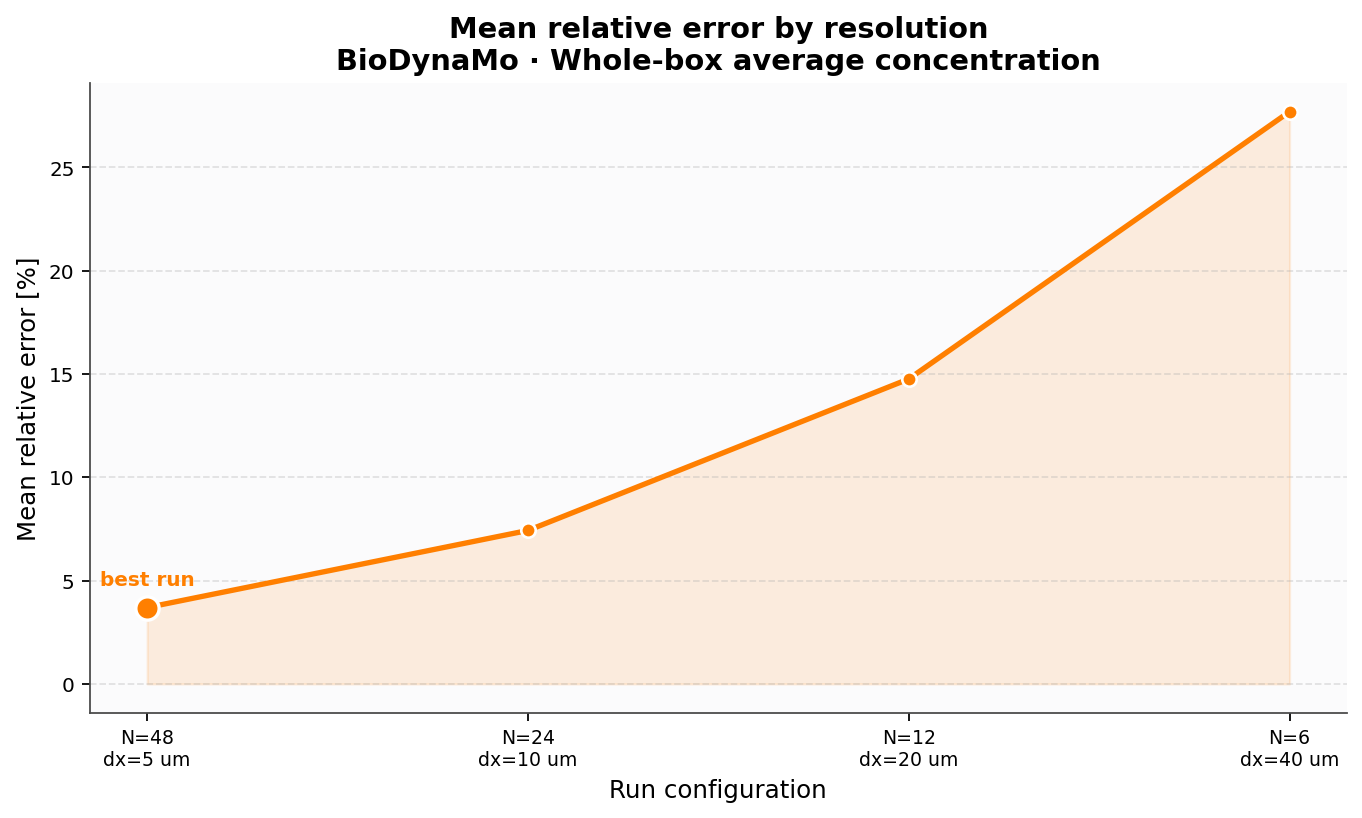

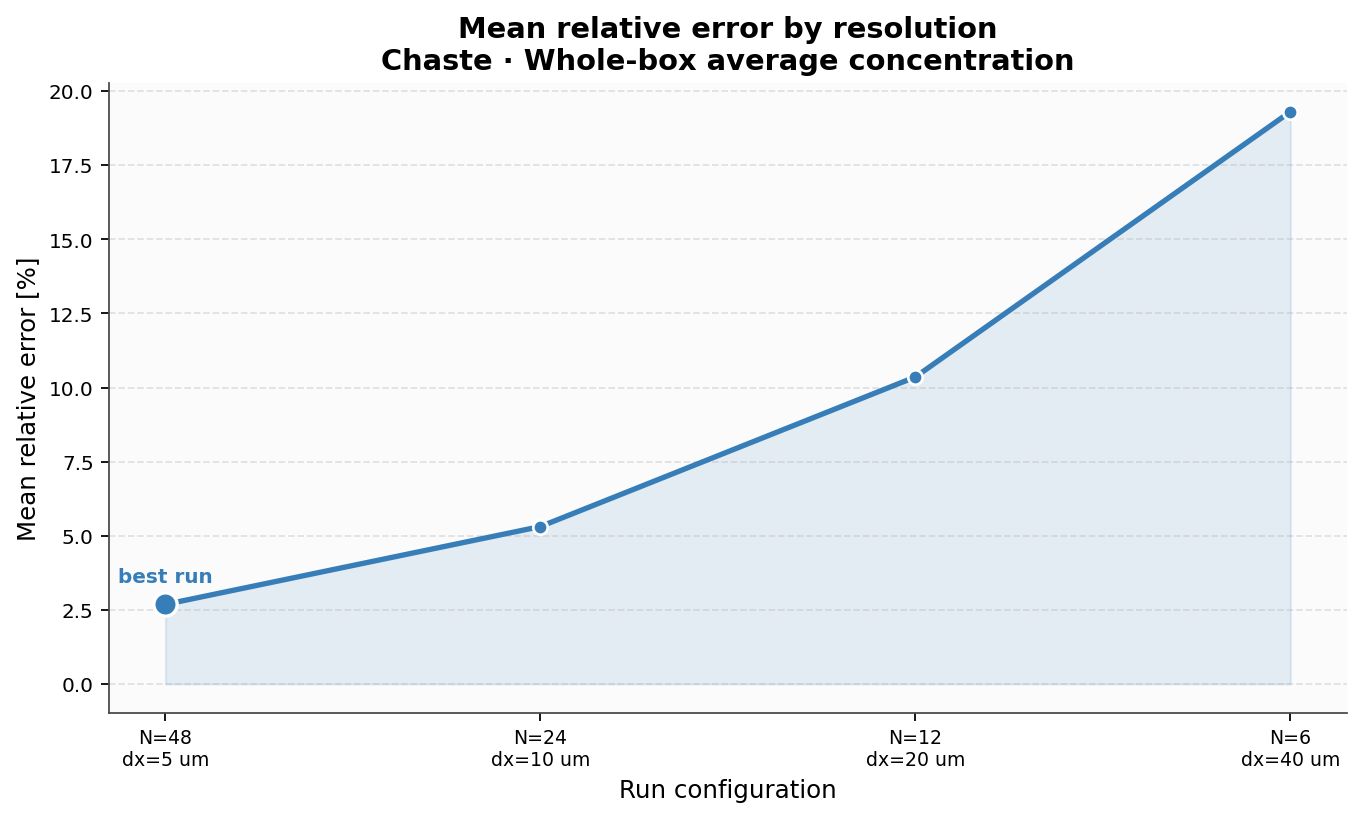

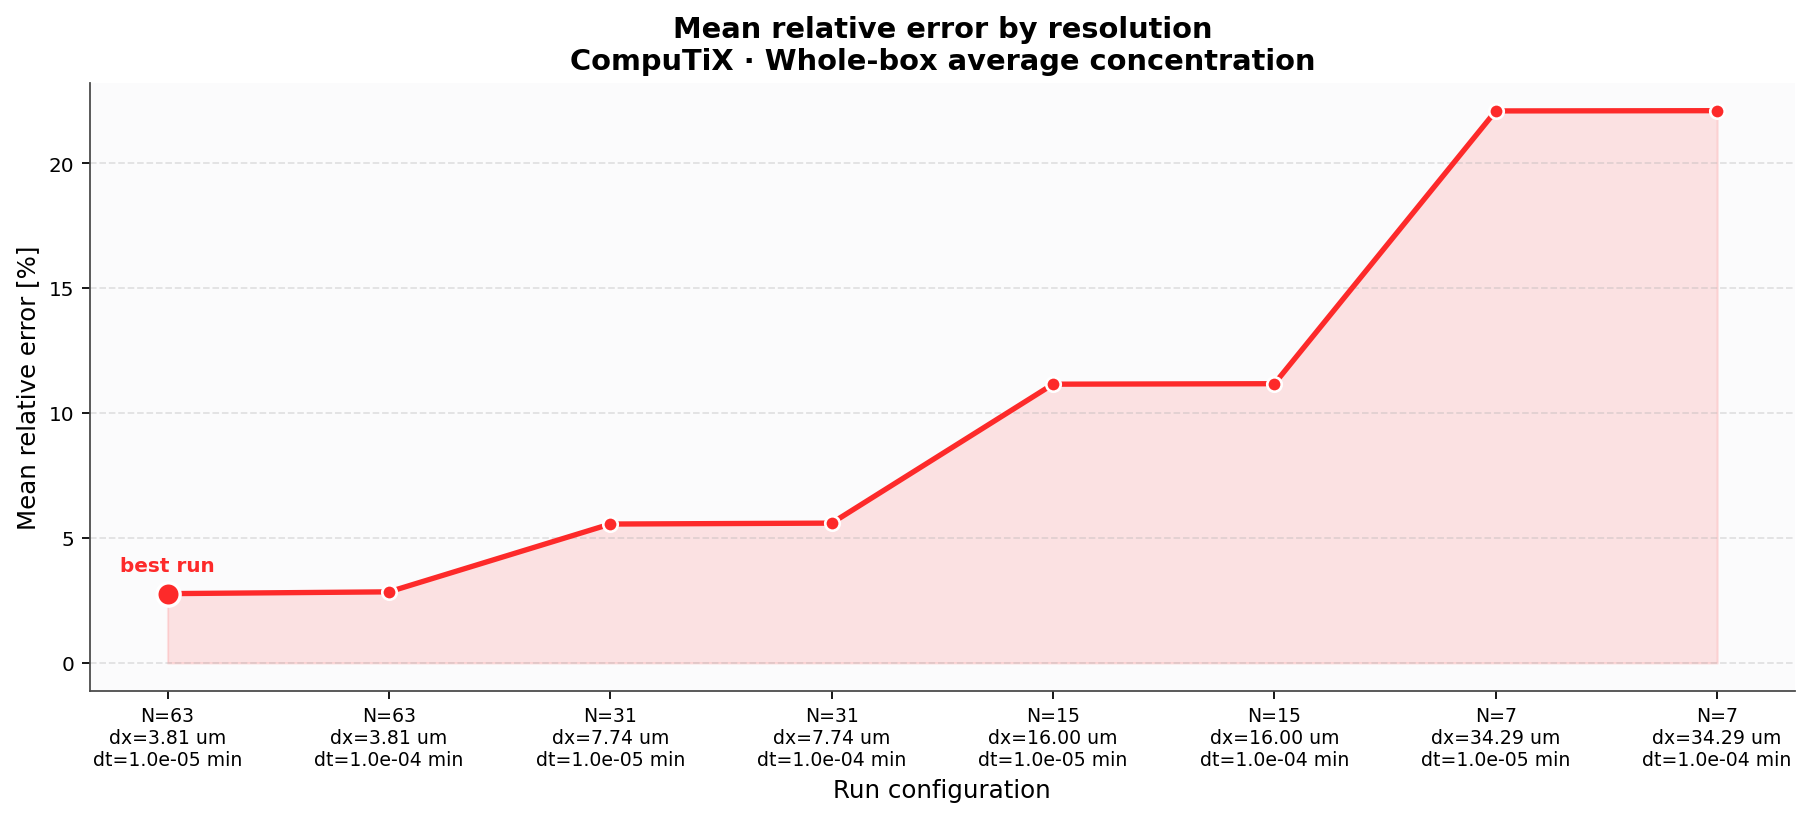

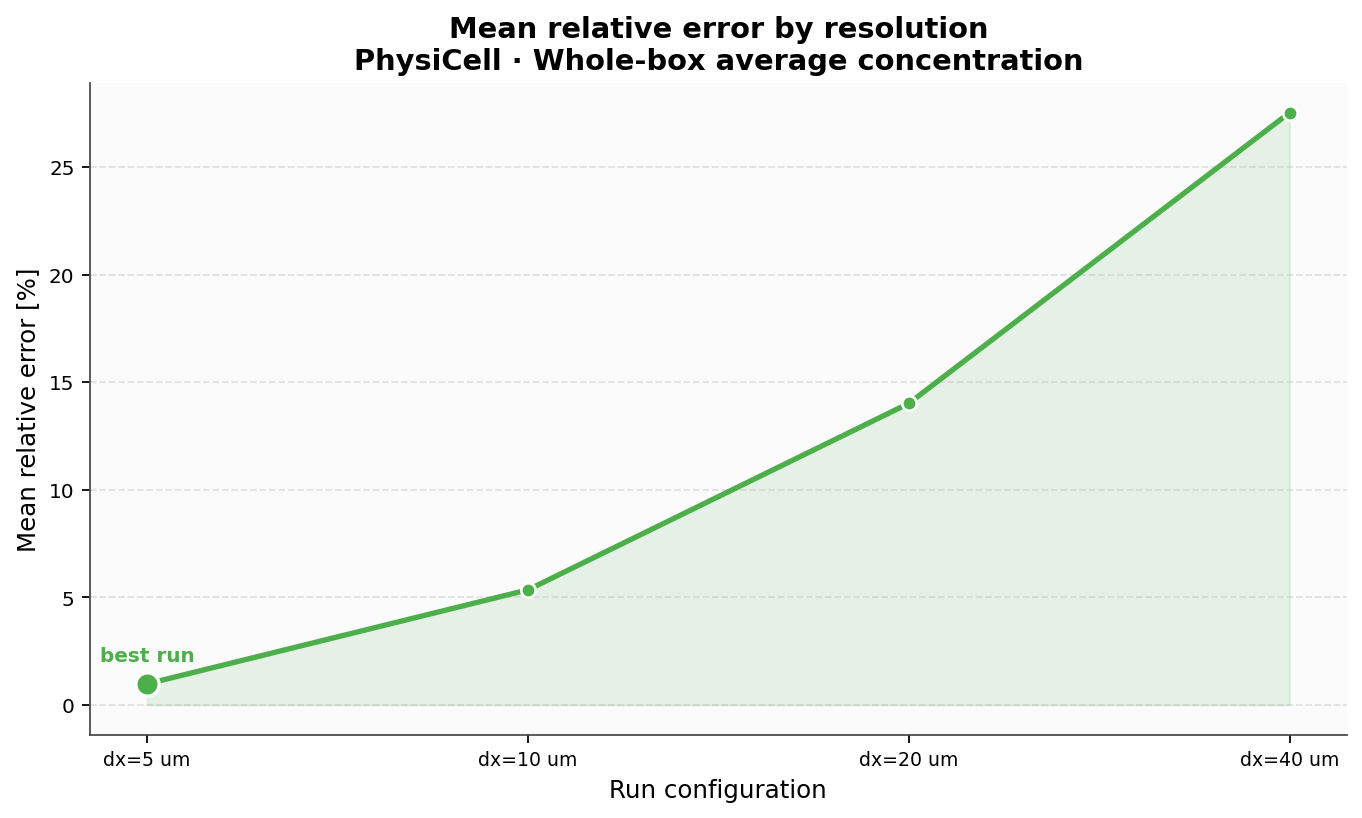

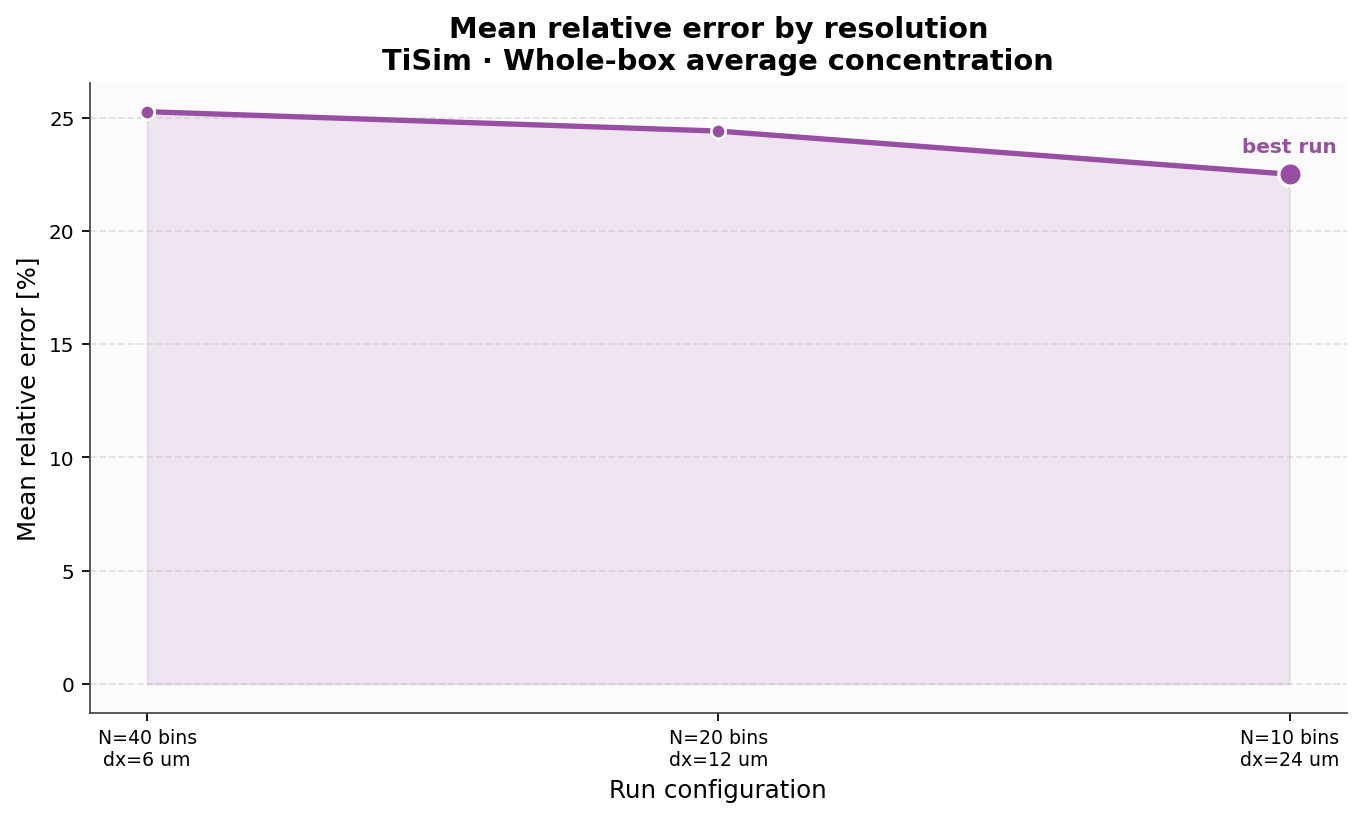

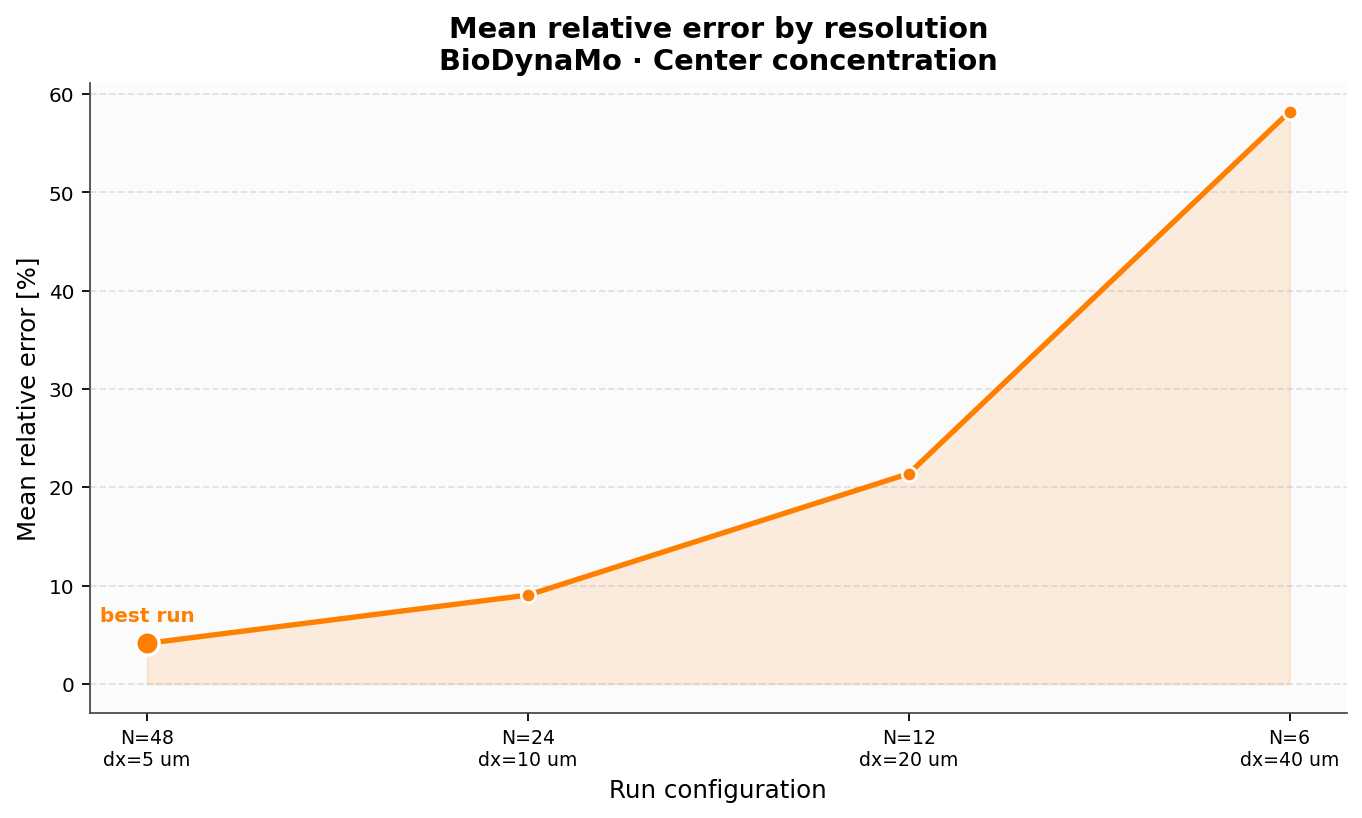

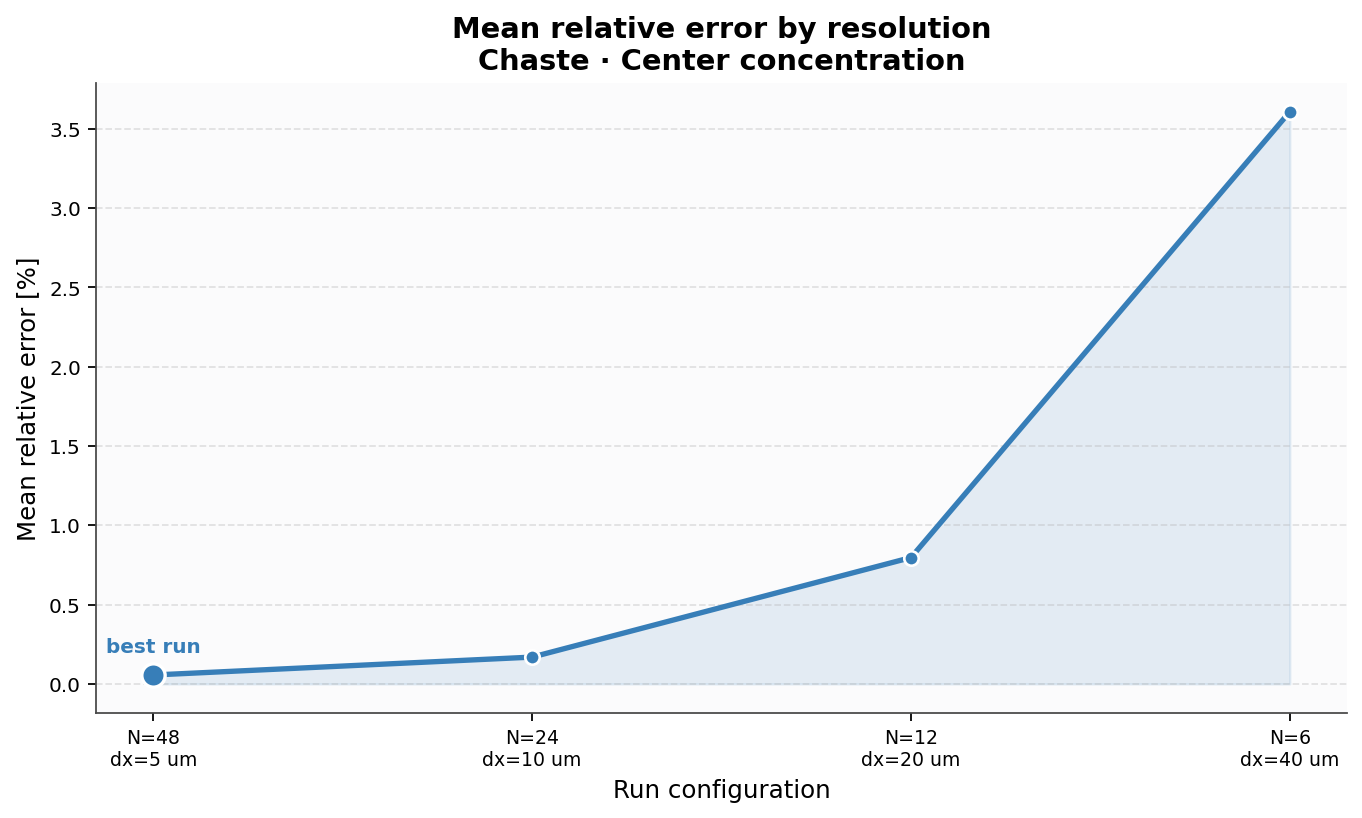

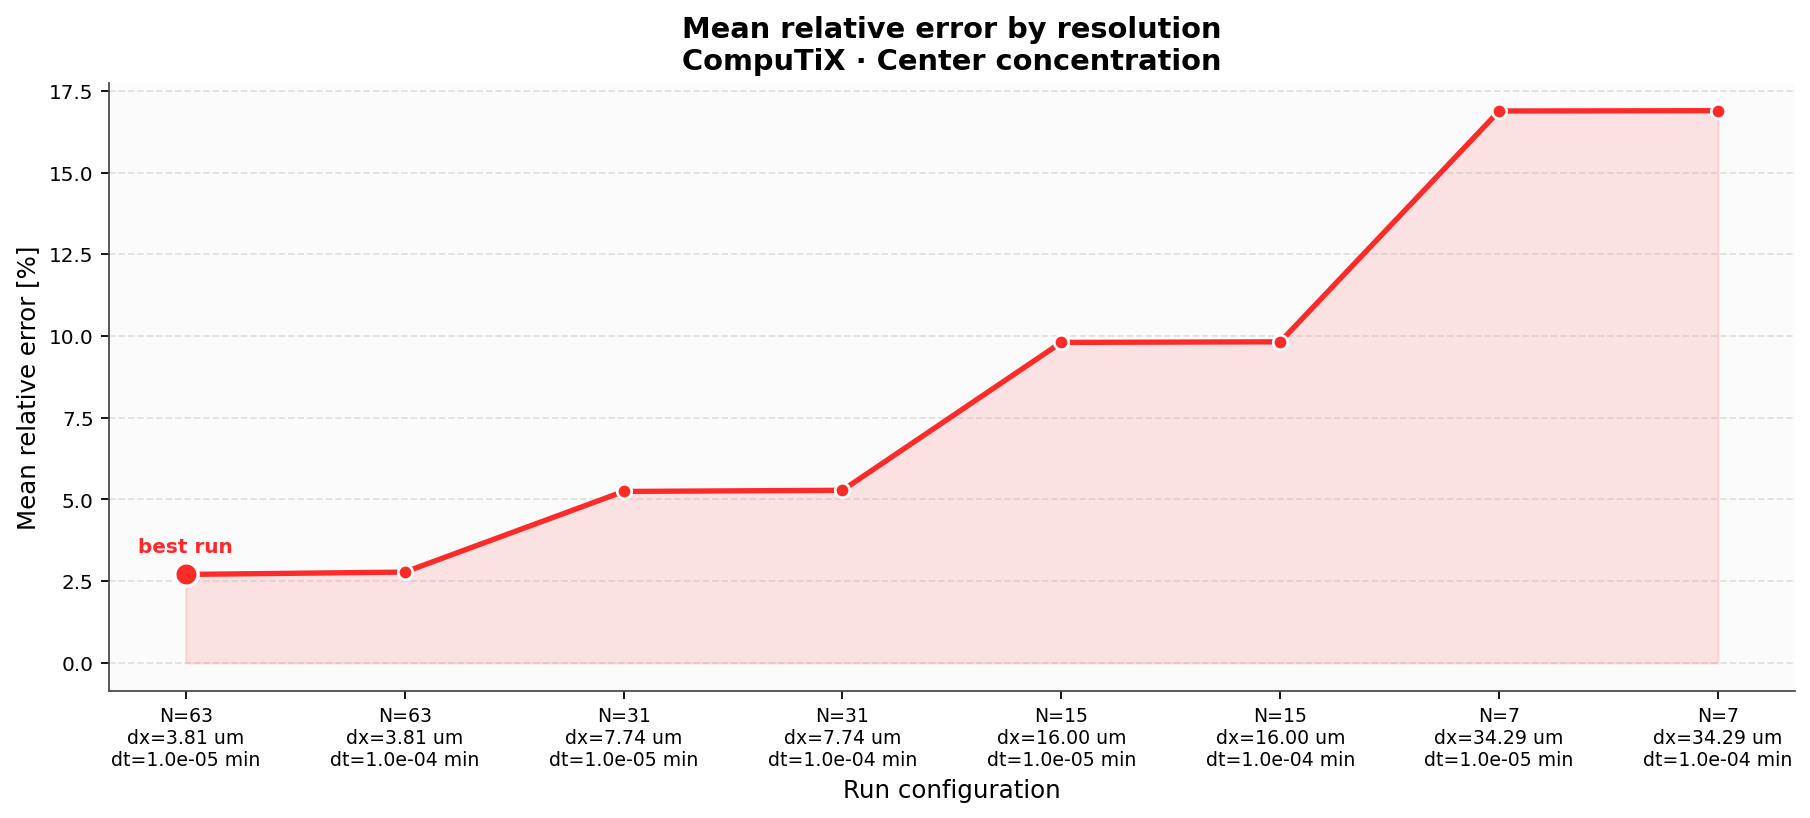

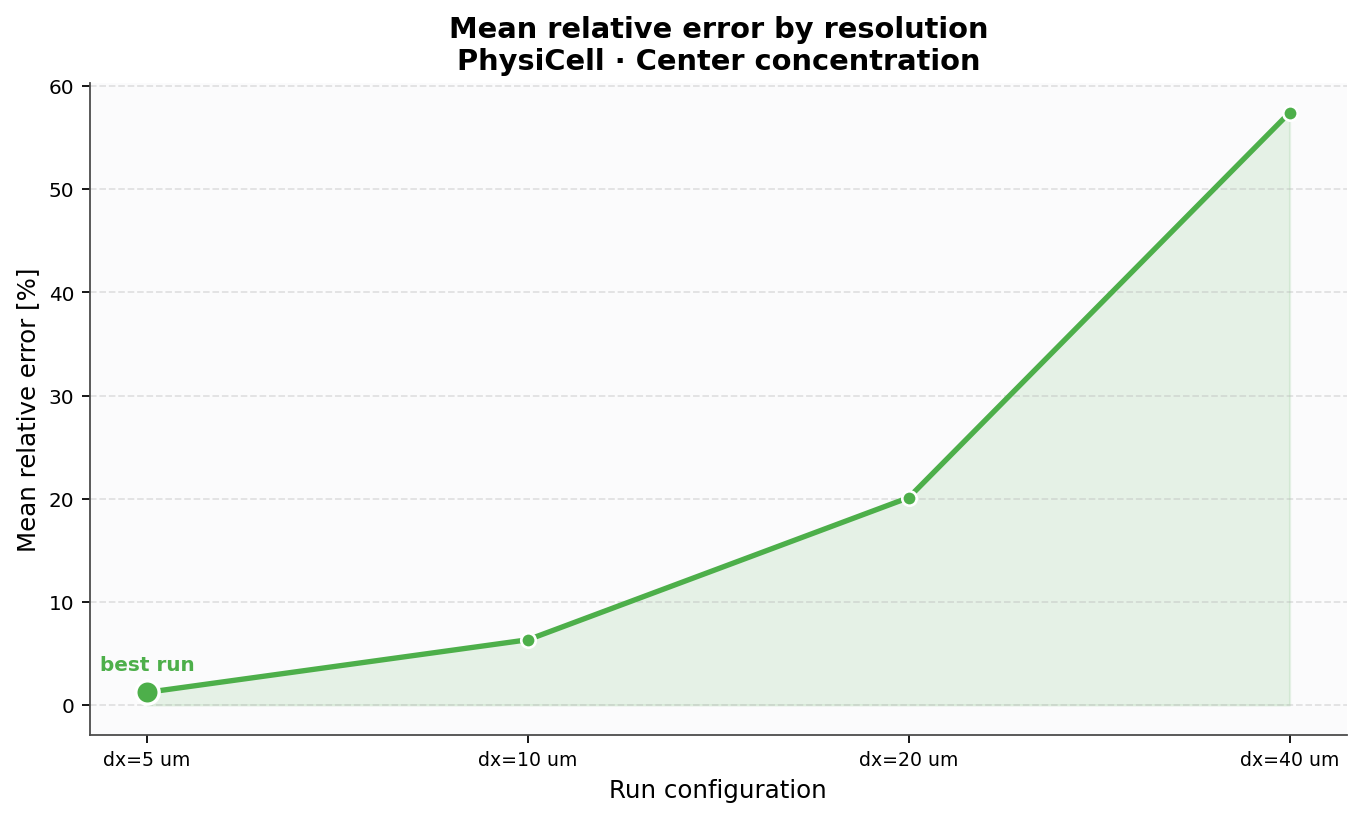

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/plots/diffusion_decay_tools_comparison_relative_plots


In [6]:
tools = sorted(run_metrics['tool'].unique())
metrics = ['average', 'center']

for metric_name in metrics:
    metric_metrics = run_metrics[run_metrics['metric'] == metric_name].copy()

    for tool_name in tools:
        tool_metrics = metric_metrics[metric_metrics['tool'] == tool_name].copy()
        if tool_metrics.empty:
            continue

        tool_metrics = tool_metrics.sort_values(['dx_um', 'dt_min'], na_position='last').reset_index(drop=True)

        tick_labels = []
        for row in tool_metrics.itertuples():
            if tool_name in {'BioDynaMo', 'Chaste'}:
                tick_labels.append(f'N={int(round(240 / row.dx_um))}\ndx={row.dx_um:.0f} um')
            elif tool_name == 'CompuTiX':
                tick_labels.append(f'N={int(round(240 / row.dx_um))}\ndx={row.dx_um:.2f} um\ndt={row.dt_min:.1e} min')
            elif tool_name == 'TiSim':
                tick_labels.append(f'N={int(round(240 / row.dx_um))} bins\ndx={row.dx_um:.0f} um')
            else:
                tick_labels.append(f'dx={row.dx_um:.0f} um')

        x_positions = np.arange(len(tool_metrics))
        y_values = tool_metrics['mean_relative_error_percent']
        best_position = int(y_values.argmin())
        figure_width = 8.4 if len(tool_metrics) <= 4 else 11.2

        fig, axis = plt.subplots(figsize=(figure_width, 5.0), constrained_layout=True)
        axis.plot(
            x_positions,
            y_values,
            color=tool_colors[tool_name],
            linewidth=2.4,
            marker='o',
            markersize=6.5,
            markeredgecolor='white',
            markeredgewidth=1.2,
        )
        axis.fill_between(x_positions, y_values, color=tool_colors[tool_name], alpha=0.12)
        axis.scatter(
            x_positions[best_position],
            y_values.iloc[best_position],
            s=110,
            color=tool_colors[tool_name],
            edgecolor='white',
            linewidth=1.5,
            zorder=3,
        )
        axis.annotate(
            'best run',
            (x_positions[best_position], y_values.iloc[best_position]),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            fontsize=9,
            color=tool_colors[tool_name],
            fontweight='semibold',
        )

        axis.set_xticks(x_positions)
        axis.set_xticklabels(tick_labels, rotation=0, ha='center')
        axis.tick_params(axis='x', labelsize=8.5)
        axis.set_ylabel('Mean relative error [%]')
        axis.set_xlabel('Run configuration')
        axis.set_title(f'Mean relative error by resolution\n{tool_name} · {metric_titles[metric_name]}')
        axis.margins(x=0.05)
        style_axis(axis)

        save_and_show(fig, f'mean_relative_error_{metric_file_tokens[metric_name]}_{tool_name.lower()}.png')

print(f'Saved standalone plots to {plot_output_dir}')

## Step 5: Keep Only The Best Resolution Per Tool And Per Metric

Now we select the run with the smallest mean relative error inside each tool family, separately for the whole-box average and for the center concentration.

This shows which resolution is closest to the analytical solution for each tool under each comparison metric.

In [7]:
best_runs = (
    run_metrics.sort_values(['metric', 'tool', 'mean_relative_error_percent', 'dx_um', 'dt_min'])
    .groupby(['metric', 'tool'], as_index=False)
    .first()
    .sort_values(['metric', 'mean_relative_error_percent'])
)

best_runs

,metric,tool,run_id,dx_um,dt_min,resolution_label,point_count,mean_relative_error_percent,max_relative_error_percent,rmse_percent
3,average,PhysiCell,PhysiCell_dx_5um,5.00000,NaN,voxel size=5 um,101,0.980275,1.084958,1.012100
1,average,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,2.684185,2.851653,2.726454
2,average,CompuTiX,CompuTiX_N_63_dt_1e-05min,3.80952,0.00001,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-05 min",100,2.774481,2.980909,2.828478
0,average,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,3.697258,3.958700,3.763585
4,average,TiSim,TiSim_N_10,24.00000,NaN,"N=10 bins, dx=24 um",13,22.508533,40.755978,26.387360
6,center,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,0.056291,0.157384,0.062886
8,center,PhysiCell,PhysiCell_dx_5um,5.00000,NaN,voxel size=5 um,101,1.222316,1.497729,1.318313
7,center,CompuTiX,CompuTiX_N_63_dt_1e-05min,3.80952,0.00001,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-05 min",100,2.707391,3.218862,2.885328
5,center,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,4.133940,4.857883,4.375633


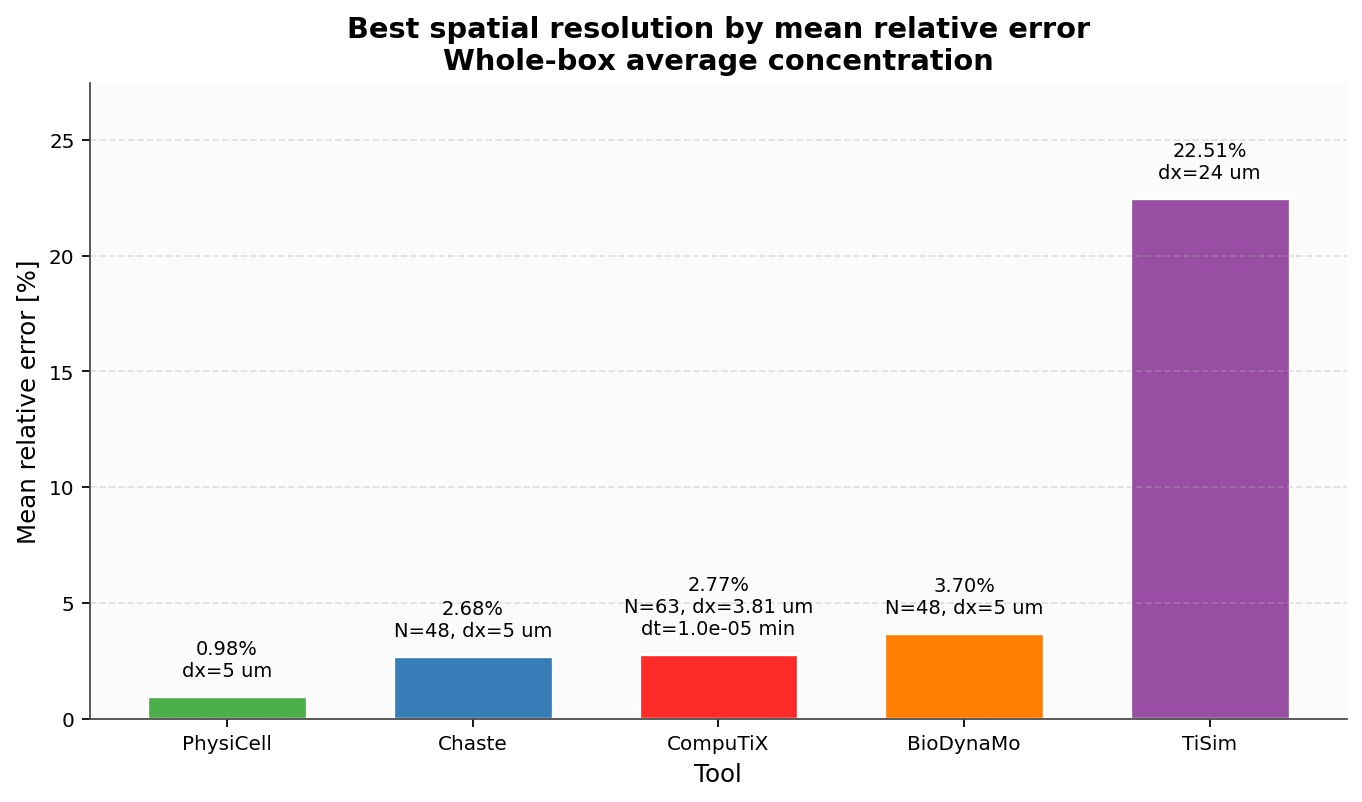

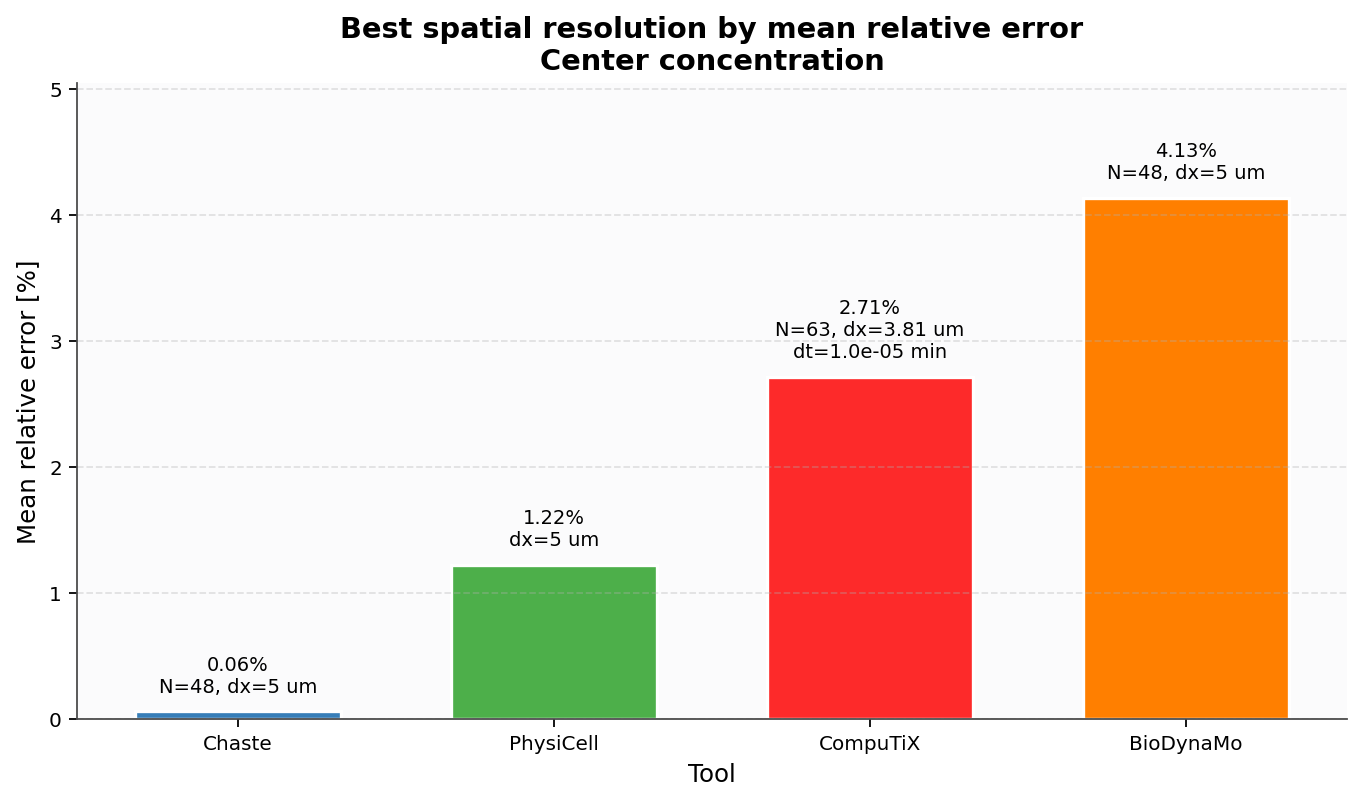

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/plots/diffusion_decay_tools_comparison_relative_plots


In [8]:
for metric_name in ['average', 'center']:
    metric_best = best_runs[best_runs['metric'] == metric_name].sort_values('mean_relative_error_percent').reset_index(drop=True)

    fig, axis = plt.subplots(figsize=(8.4, 4.9), constrained_layout=True)
    bars = axis.bar(
        metric_best['tool'],
        metric_best['mean_relative_error_percent'],
        width=0.65,
        color=[tool_colors[tool_name] for tool_name in metric_best['tool']],
        edgecolor='white',
        linewidth=1.5,
    )

    for bar, (_, row) in zip(bars, metric_best.iterrows()):
        if row['tool'] == 'CompuTiX':
            resolution_text = f"N={int(round(240 / row['dx_um']))}, dx={row['dx_um']:.2f} um\ndt={row['dt_min']:.1e} min"
        elif row['tool'] in {'BioDynaMo', 'Chaste'}:
            resolution_text = f"N={int(round(240 / row['dx_um']))}, dx={row['dx_um']:.0f} um"
        else:
            resolution_text = f"dx={row['dx_um']:.0f} um"

        axis.text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() + 0.03 * metric_best['mean_relative_error_percent'].max(),
            f"{row['mean_relative_error_percent']:.2f}%\n{resolution_text}",
            ha='center',
            va='bottom',
            fontsize=8.8,
        )

    axis.set_ylabel('Mean relative error [%]')
    axis.set_xlabel('Tool')
    axis.set_title(f'Best spatial resolution by mean relative error\n{metric_titles[metric_name]}')
    axis.set_ylim(0, metric_best['mean_relative_error_percent'].max() * 1.22)
    style_axis(axis)

    save_and_show(fig, f'best_resolution_{metric_file_tokens[metric_name]}.png')

print(f'Saved standalone plots to {plot_output_dir}')

## Step 6: Plot The Relative Error Over Time For Only The Best Runs

This is the final comparison: one relative-error curve per tool for the best run selected under the whole-box average metric, and one relative-error curve per tool for the best run selected under the center metric.

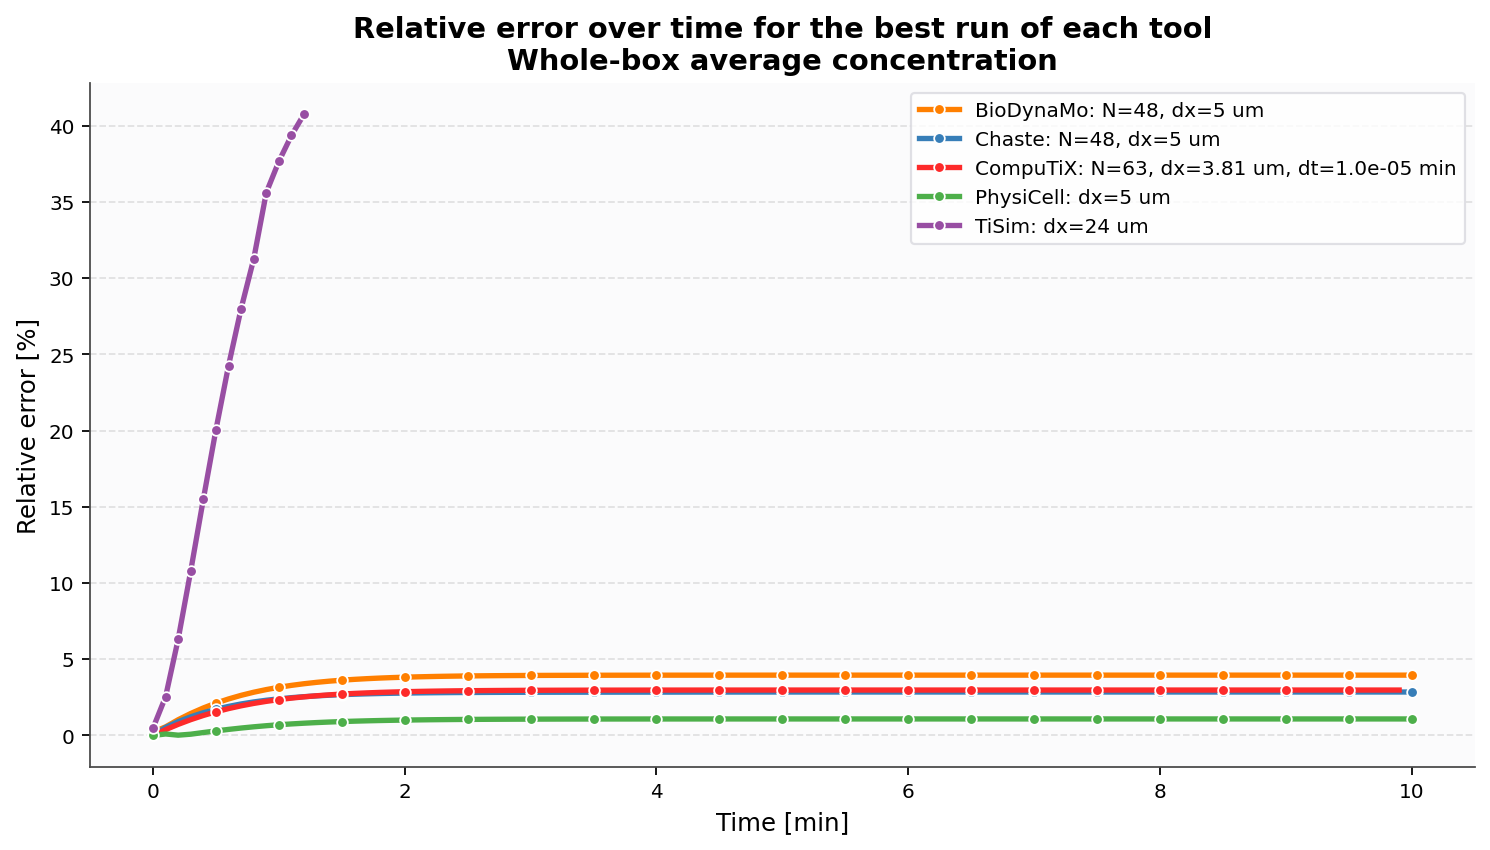

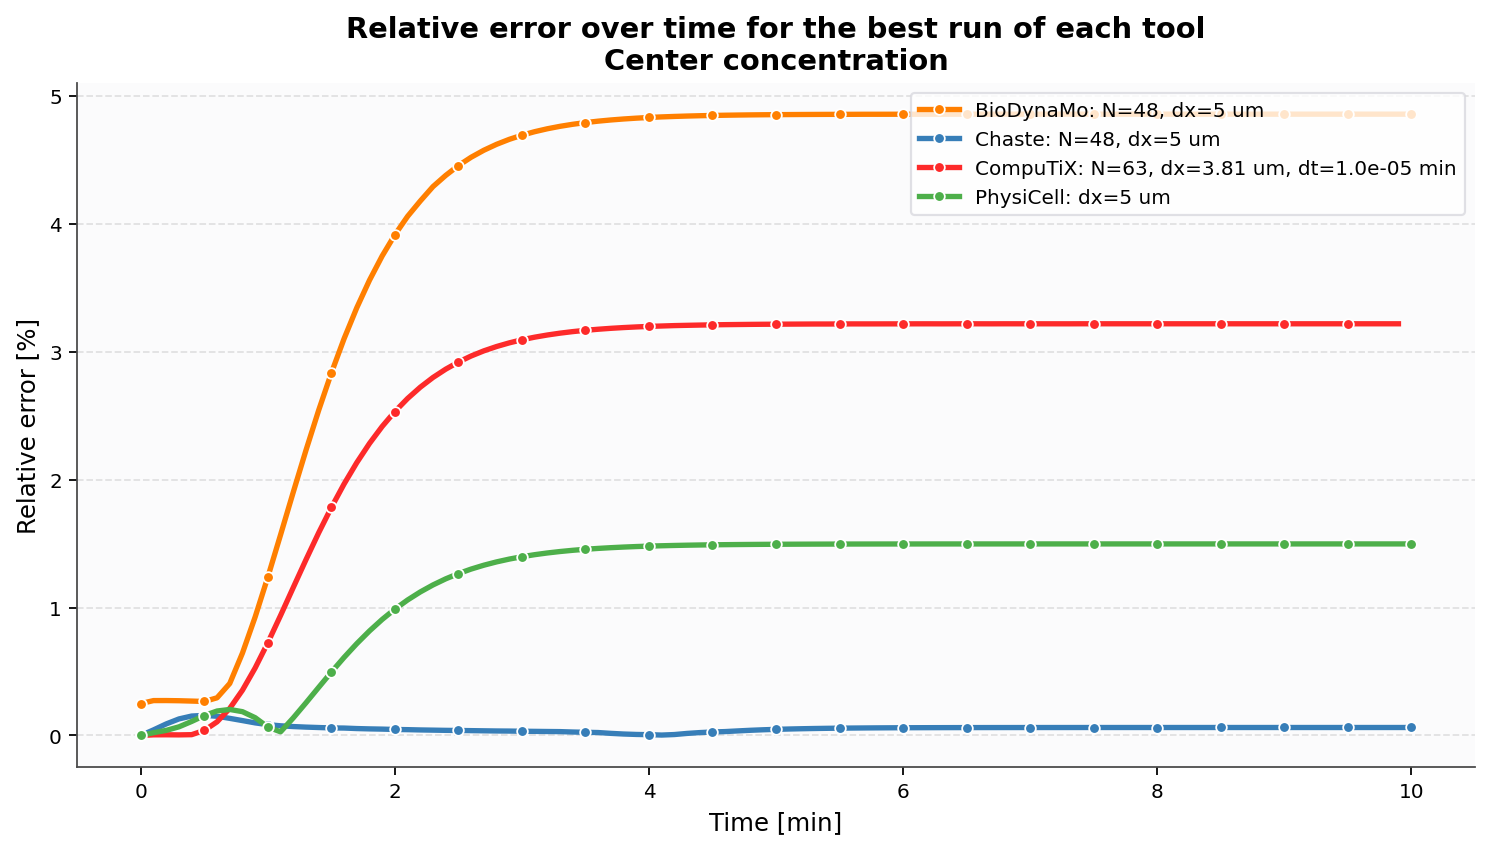

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/plots/diffusion_decay_tools_comparison_relative_plots


In [9]:
for metric_name in ['average', 'center']:
    metric_best_runs = best_runs[best_runs['metric'] == metric_name][['tool', 'run_id']]
    metric_comparison = comparison[comparison['metric'] == metric_name].merge(
        metric_best_runs,
        on=['tool', 'run_id'],
        how='inner',
        validate='many_to_one',
    )

    fig, axis = plt.subplots(figsize=(9.2, 5.2), constrained_layout=True)

    for tool_name, group in metric_comparison.groupby('tool'):
        group = group.sort_values('time_min').reset_index(drop=True)
        marker_step = max(len(group) // 18, 1)

        if tool_name == 'CompuTiX':
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))}, dx={group['dx_um'].iloc[0]:.2f} um, dt={group['dt_min'].iloc[0]:.1e} min"
        elif tool_name in {'BioDynaMo', 'Chaste'}:
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))}, dx={group['dx_um'].iloc[0]:.0f} um"
        else:
            resolution_text = f"dx={group['dx_um'].iloc[0]:.0f} um"

        axis.plot(
            group['time_min'],
            group['relative_error_percent'],
            color=tool_colors[tool_name],
            linewidth=2.4,
            marker='o',
            markersize=4.8,
            markeredgecolor='white',
            markeredgewidth=0.8,
            markevery=marker_step,
            label=f"{tool_name}: {resolution_text}",
        )

    axis.set_xlabel('Time [min]')
    axis.set_ylabel('Relative error [%]')
    axis.set_title(f'Relative error over time for the best run of each tool\n{metric_titles[metric_name]}')
    style_axis(axis)
    axis.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#d9d9df')

    save_and_show(fig, f'relative_error_over_time_{metric_file_tokens[metric_name]}.png')

print(f'Saved standalone plots to {plot_output_dir}')

## Step 7: Plot Absolute Error For The Best Run Of Each Tool

This section reuses the same common rounded-time matching and duplicate-match aggregation used above, including the BioDynaMo handling from solution 1.

We compute the absolute error in uM, rank runs by mean absolute error, then compare the best run from each tool for the whole-box average and for the center concentration.

In [10]:
absolute_comparison = comparison.copy()
absolute_comparison['absolute_error_uM'] = (
    absolute_comparison['simulated_uM'] - absolute_comparison['analytical_uM']
).abs()

absolute_run_metrics = (
    absolute_comparison.groupby(['metric', 'tool', 'run_id', 'dx_um', 'dt_min', 'resolution_label'], dropna=False)
    .agg(
        point_count=('time_min', 'size'),
        mean_absolute_error_uM=('absolute_error_uM', 'mean'),
        max_absolute_error_uM=('absolute_error_uM', 'max'),
        rmse_uM=('absolute_error_uM', lambda values: np.sqrt(np.mean(np.square(values)))),
    )
    .reset_index()
    .sort_values(['metric', 'tool', 'mean_absolute_error_uM', 'dx_um', 'dt_min'])
)

absolute_best_runs = (
    absolute_run_metrics.sort_values(['metric', 'tool', 'mean_absolute_error_uM', 'dx_um', 'dt_min'])
    .groupby(['metric', 'tool'], as_index=False)
    .first()
    .sort_values(['metric', 'mean_absolute_error_uM'])
)

absolute_best_runs

,metric,tool,run_id,dx_um,dt_min,resolution_label,point_count,mean_absolute_error_uM,max_absolute_error_uM,rmse_uM
3,average,PhysiCell,PhysiCell_dx_5um,5.00000,NaN,voxel size=5 um,101,0.067601,0.074407,0.069632
1,average,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,0.185899,0.195569,0.188256
2,average,CompuTiX,CompuTiX_N_63_dt_1e-05min,3.80952,0.00001,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-05 min",100,0.191948,0.204433,0.195080
0,average,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,0.255892,0.271491,0.259619
4,average,TiSim,TiSim_N_10,24.00000,NaN,"N=10 bins, dx=24 um",13,1.680579,2.889447,1.937027
6,center,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,0.001961,0.010205,0.002712
8,center,PhysiCell,PhysiCell_dx_5um,5.00000,NaN,voxel size=5 um,101,0.034452,0.041475,0.036738
7,center,CompuTiX,CompuTiX_N_63_dt_1e-05min,3.80952,0.00001,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-05 min",100,0.076330,0.089136,0.080691
5,center,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,0.116505,0.134523,0.122486


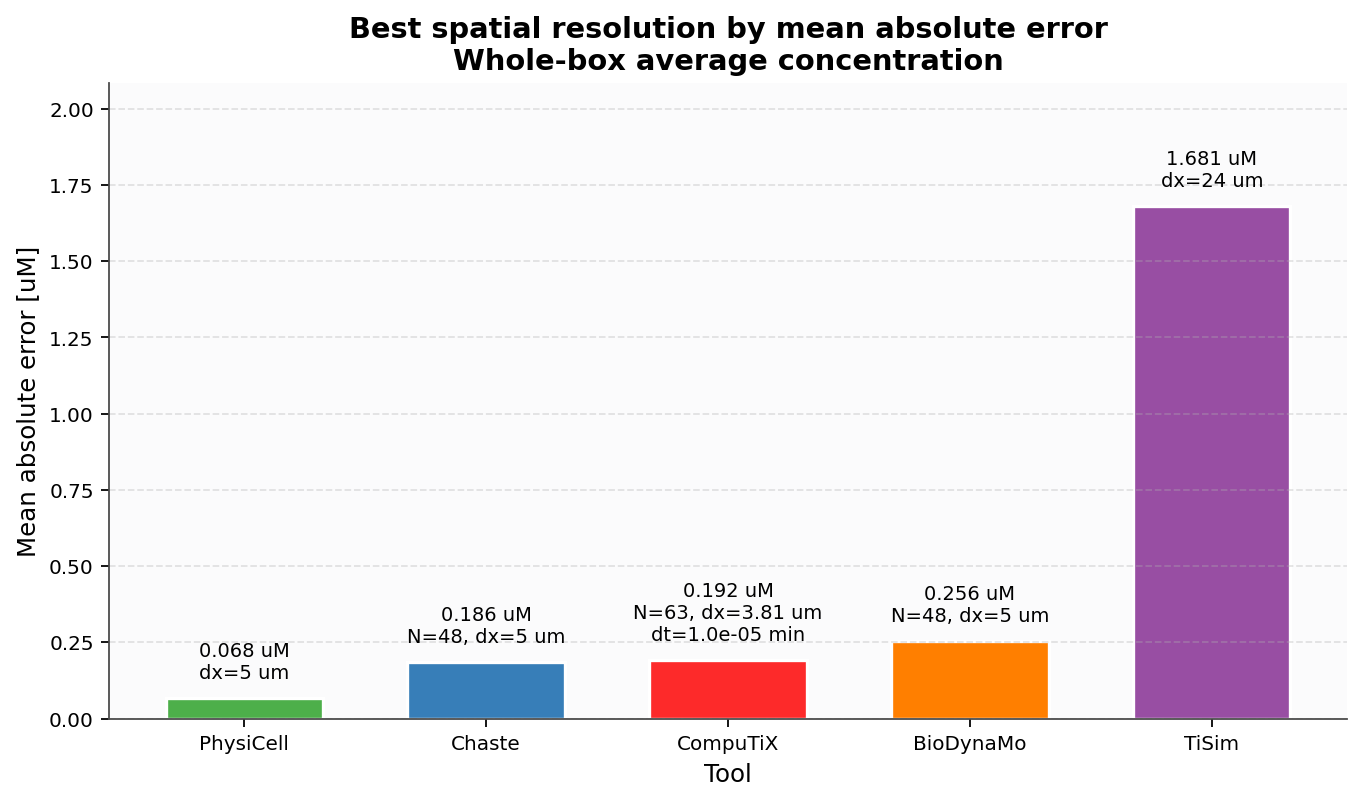

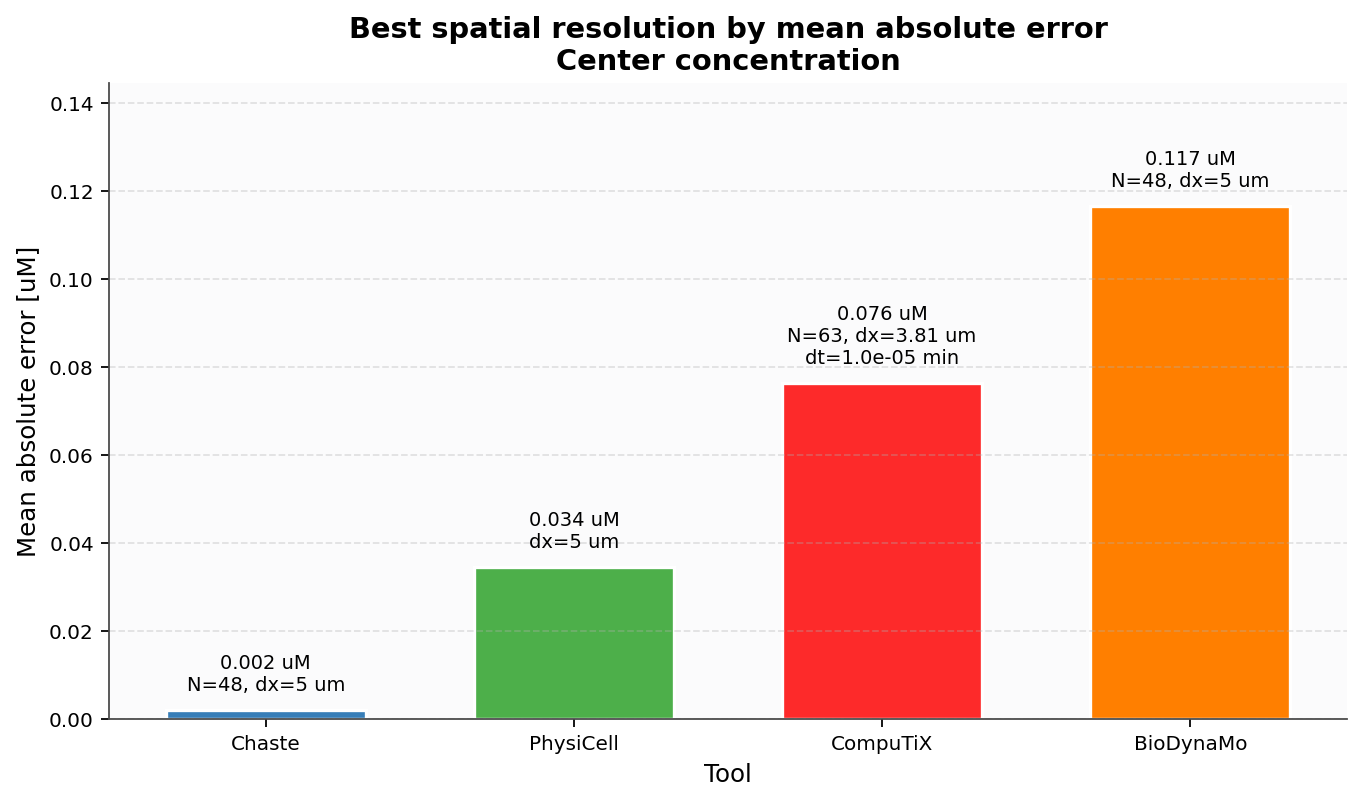

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/plots/diffusion_decay_tools_comparison_relative_plots


In [11]:
for metric_name in ['average', 'center']:
    metric_best = absolute_best_runs[absolute_best_runs['metric'] == metric_name].sort_values('mean_absolute_error_uM').reset_index(drop=True)

    fig, axis = plt.subplots(figsize=(8.4, 4.9), constrained_layout=True)
    bars = axis.bar(
        metric_best['tool'],
        metric_best['mean_absolute_error_uM'],
        width=0.65,
        color=[tool_colors[tool_name] for tool_name in metric_best['tool']],
        edgecolor='white',
        linewidth=1.5,
    )

    for bar, (_, row) in zip(bars, metric_best.iterrows()):
        if row['tool'] == 'CompuTiX':
            resolution_text = f"N={int(round(240 / row['dx_um']))}, dx={row['dx_um']:.2f} um\ndt={row['dt_min']:.1e} min"
        elif row['tool'] in {'BioDynaMo', 'Chaste'}:
            resolution_text = f"N={int(round(240 / row['dx_um']))}, dx={row['dx_um']:.0f} um"
        else:
            resolution_text = f"dx={row['dx_um']:.0f} um"

        axis.text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() + 0.03 * metric_best['mean_absolute_error_uM'].max(),
            f"{row['mean_absolute_error_uM']:.3f} uM\n{resolution_text}",
            ha='center',
            va='bottom',
            fontsize=8.8,
        )

    axis.set_ylabel('Mean absolute error [uM]')
    axis.set_xlabel('Tool')
    axis.set_title(f'Best spatial resolution by mean absolute error\n{metric_titles[metric_name]}')
    axis.set_ylim(0, metric_best['mean_absolute_error_uM'].max() * 1.24)
    style_axis(axis)

    save_and_show(fig, f'best_absolute_resolution_{metric_file_tokens[metric_name]}.png')

print(f'Saved standalone plots to {plot_output_dir}')

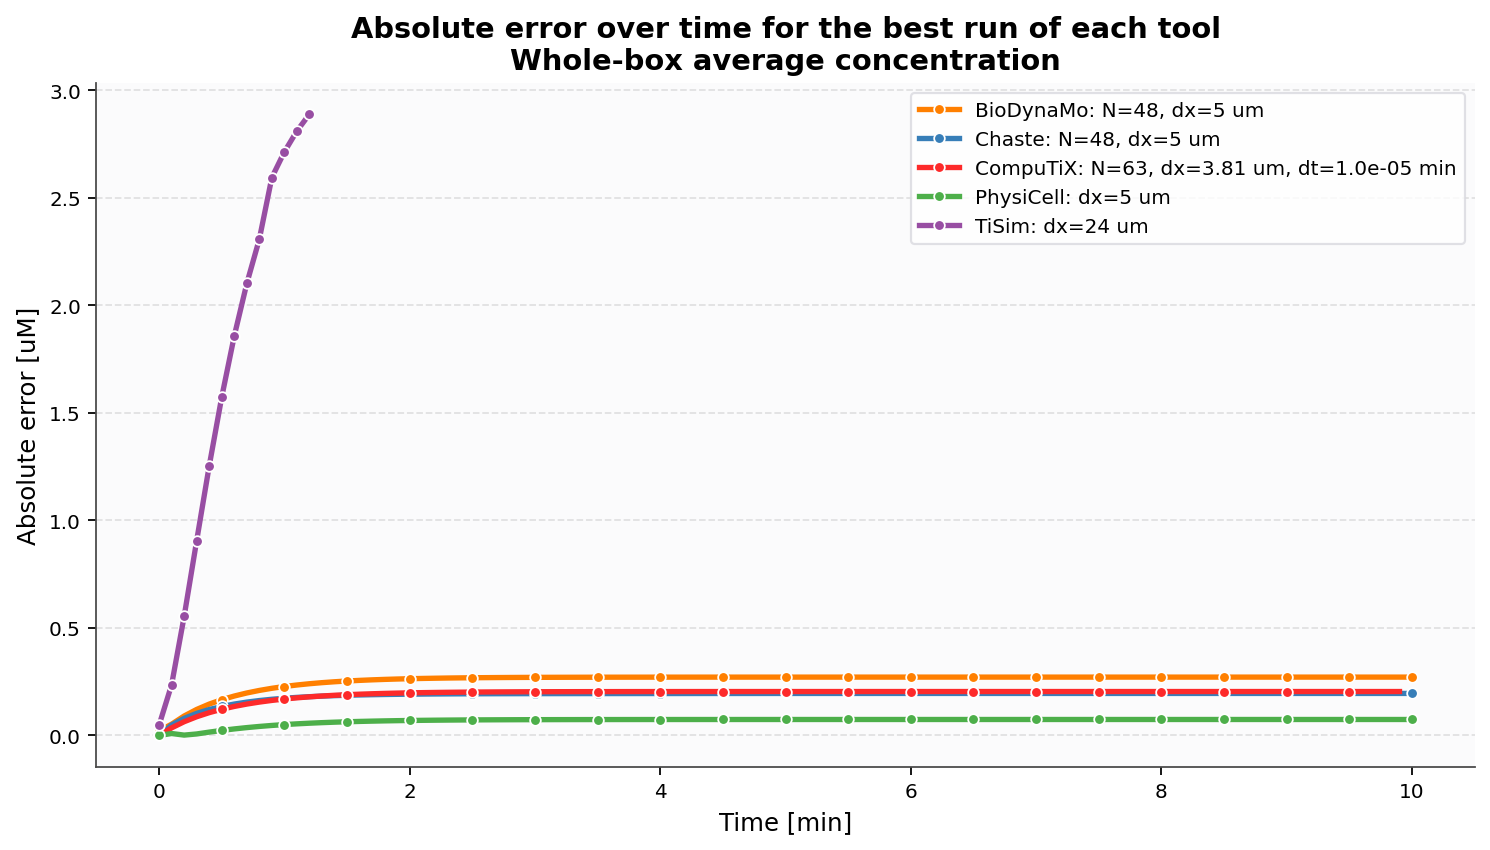

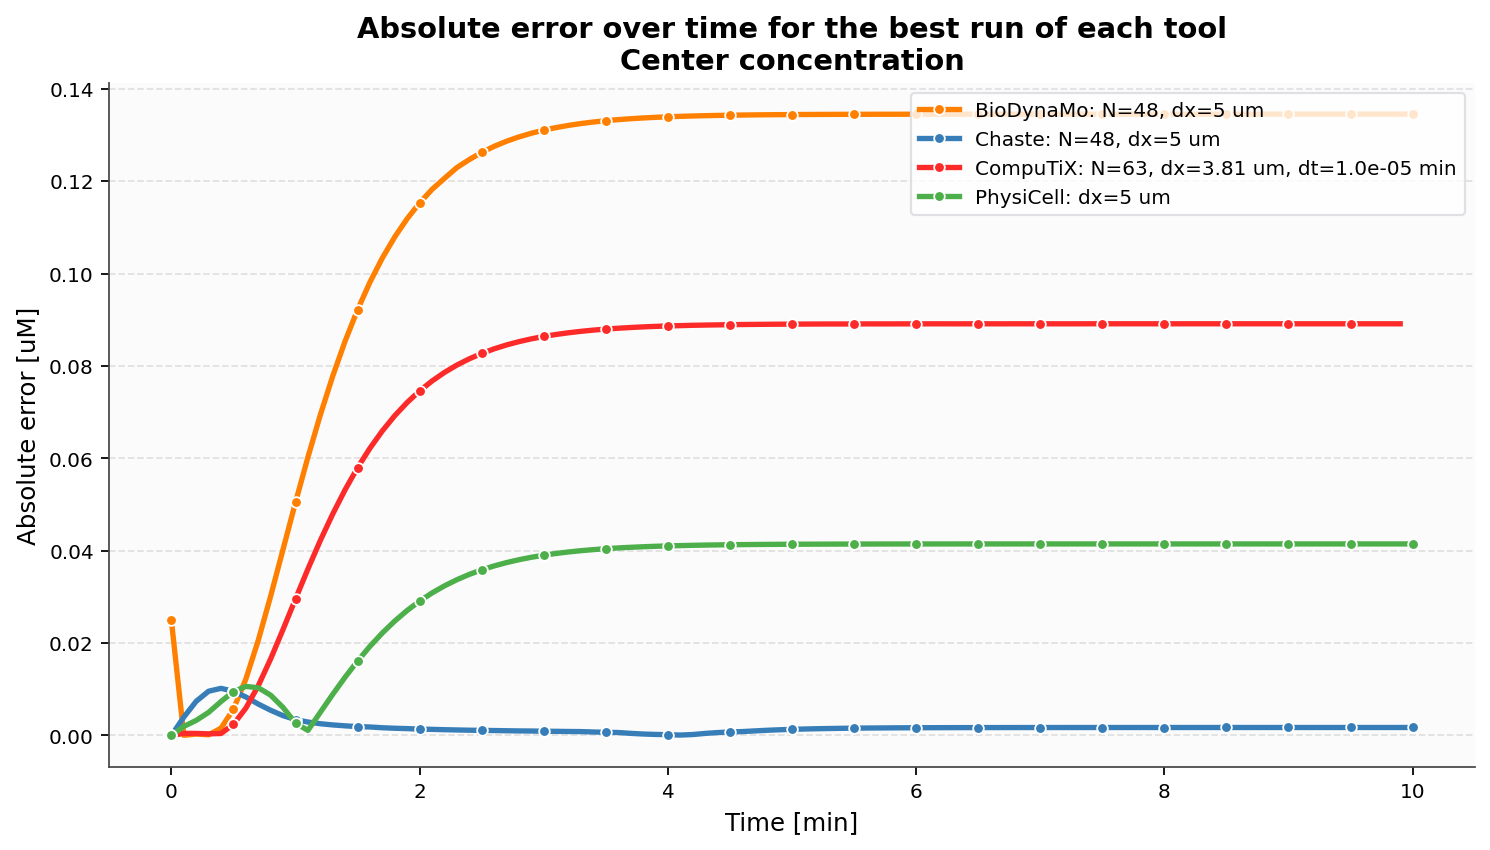

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/plots/diffusion_decay_tools_comparison_relative_plots


In [12]:
for metric_name in ['average', 'center']:
    metric_best_runs = absolute_best_runs[absolute_best_runs['metric'] == metric_name][['tool', 'run_id']]
    metric_comparison = absolute_comparison[absolute_comparison['metric'] == metric_name].merge(
        metric_best_runs,
        on=['tool', 'run_id'],
        how='inner',
        validate='many_to_one',
    )

    fig, axis = plt.subplots(figsize=(9.2, 5.2), constrained_layout=True)

    for tool_name, group in metric_comparison.groupby('tool'):
        group = group.sort_values('time_min').reset_index(drop=True)
        marker_step = max(len(group) // 18, 1)

        if tool_name == 'CompuTiX':
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))}, dx={group['dx_um'].iloc[0]:.2f} um, dt={group['dt_min'].iloc[0]:.1e} min"
        elif tool_name in {'BioDynaMo', 'Chaste'}:
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))}, dx={group['dx_um'].iloc[0]:.0f} um"
        else:
            resolution_text = f"dx={group['dx_um'].iloc[0]:.0f} um"

        axis.plot(
            group['time_min'],
            group['absolute_error_uM'],
            color=tool_colors[tool_name],
            linewidth=2.4,
            marker='o',
            markersize=4.8,
            markeredgecolor='white',
            markeredgewidth=0.8,
            markevery=marker_step,
            label=f"{tool_name}: {resolution_text}",
        )

    axis.set_xlabel('Time [min]')
    axis.set_ylabel('Absolute error [uM]')
    axis.set_title(f'Absolute error over time for the best run of each tool\n{metric_titles[metric_name]}')
    style_axis(axis)
    axis.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#d9d9df')

    save_and_show(fig, f'absolute_error_over_time_{metric_file_tokens[metric_name]}.png')

print(f'Saved standalone plots to {plot_output_dir}')

## Step 8: Recompute Errors With Interpolated Analytical Values

This section keeps the original rounded-time matching workflow intact and adds a second comparison path where the analytical reference is interpolated directly onto each simulation time grid.

The goal is to compare the two alignment strategies side by side before deciding which one is the better basis for cross-tool benchmarking.

In [13]:
interpolation_reference = (
    analytical_df.groupby('time_min', as_index=False)[
        ['average_concentration_uM', 'center_concentration_uM']
    ]
    .mean()
    .sort_values('time_min')
)

interpolation_time_min = interpolation_reference['time_min'].to_numpy(dtype=float)
interpolation_average_uM = interpolation_reference['average_concentration_uM'].to_numpy(dtype=float)
interpolation_center_uM = interpolation_reference['center_concentration_uM'].to_numpy(dtype=float)

interpolated_comparison = all_runs.copy()
interpolated_comparison['analytical_average_uM'] = np.interp(
    interpolated_comparison['time_min'].to_numpy(dtype=float),
    interpolation_time_min,
    interpolation_average_uM,
 )
interpolated_comparison['analytical_center_uM'] = np.interp(
    interpolated_comparison['time_min'].to_numpy(dtype=float),
    interpolation_time_min,
    interpolation_center_uM,
 )

interpolated_average = interpolated_comparison.assign(
    metric='average',
    simulated_uM=interpolated_comparison['average_uM'],
    analytical_uM=interpolated_comparison['analytical_average_uM'],
    source_column=interpolated_comparison['average_source'],
)

interpolated_center = interpolated_comparison[interpolated_comparison['center_uM'].notna()].assign(
    metric='center',
    simulated_uM=lambda frame: frame['center_uM'],
    analytical_uM=lambda frame: frame['analytical_center_uM'],
    source_column=lambda frame: frame['center_source'],
)

interpolated_comparison = pd.concat([interpolated_average, interpolated_center], ignore_index=True)
interpolated_comparison['relative_error_percent'] = (
    100.0
    * (interpolated_comparison['simulated_uM'] - interpolated_comparison['analytical_uM']).abs()
    / interpolated_comparison['analytical_uM'].abs()
)
interpolated_comparison['absolute_error_uM'] = (
    interpolated_comparison['simulated_uM'] - interpolated_comparison['analytical_uM']
 ).abs()

interpolated_relative_run_metrics = (
    interpolated_comparison.groupby(['metric', 'tool', 'run_id', 'dx_um', 'dt_min', 'resolution_label'], dropna=False)
    .agg(
        point_count=('time_min', 'size'),
        mean_relative_error_percent=('relative_error_percent', 'mean'),
        max_relative_error_percent=('relative_error_percent', 'max'),
        rmse_percent=('relative_error_percent', lambda values: np.sqrt(np.mean(np.square(values)))),
    )
    .reset_index()
    .sort_values(['metric', 'tool', 'mean_relative_error_percent', 'dx_um', 'dt_min'])
)

interpolated_best_runs = (
    interpolated_relative_run_metrics
    .sort_values(['metric', 'tool', 'mean_relative_error_percent', 'dx_um', 'dt_min'])
    .groupby(['metric', 'tool'], as_index=False)
    .first()
    .sort_values(['metric', 'mean_relative_error_percent'])
)

interpolated_absolute_run_metrics = (
    interpolated_comparison.groupby(['metric', 'tool', 'run_id', 'dx_um', 'dt_min', 'resolution_label'], dropna=False)
    .agg(
        point_count=('time_min', 'size'),
        mean_absolute_error_uM=('absolute_error_uM', 'mean'),
        max_absolute_error_uM=('absolute_error_uM', 'max'),
        rmse_uM=('absolute_error_uM', lambda values: np.sqrt(np.mean(np.square(values)))),
    )
    .reset_index()
    .sort_values(['metric', 'tool', 'mean_absolute_error_uM', 'dx_um', 'dt_min'])
)

interpolated_absolute_best_runs = (
    interpolated_absolute_run_metrics
    .sort_values(['metric', 'tool', 'mean_absolute_error_uM', 'dx_um', 'dt_min'])
    .groupby(['metric', 'tool'], as_index=False)
    .first()
    .sort_values(['metric', 'mean_absolute_error_uM'])
)

interpolated_relative_run_metrics

,metric,tool,run_id,dx_um,dt_min,resolution_label,point_count,mean_relative_error_percent,max_relative_error_percent,rmse_percent
2,average,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",10000,3.705995,3.958721,3.768802
1,average,BioDynaMo,BioDynaMo_N_24,10.00000,NaN,"N=24 voxels/dim, dx=10 um",10000,7.453651,7.943823,7.573531
0,average,BioDynaMo,BioDynaMo_N_12,20.00000,NaN,"N=12 voxels/dim, dx=20 um",1000,14.823538,15.774800,15.054186
3,average,BioDynaMo,BioDynaMo_N_6,40.00000,NaN,"N=6 voxels/dim, dx=40 um",1000,27.822446,29.500724,28.225149
6,average,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",1001,2.688796,2.851653,2.728541
5,average,Chaste,Chaste_N_24,10.00000,NaN,"N=24 voxels/dim, dx=10 um",1001,5.325647,5.639602,5.402566
4,average,Chaste,Chaste_N_12,20.00000,NaN,"N=12 voxels/dim, dx=20 um",1001,10.395211,11.002099,10.541578
7,average,Chaste,Chaste_N_6,40.00000,NaN,"N=6 voxels/dim, dx=40 um",1001,19.384370,20.519042,19.655235
13,average,CompuTiX,CompuTiX_N_63_dt_1e-05min,3.80952,0.00001,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-05 min",100,2.774481,2.980909,2.828478
12,average,CompuTiX,CompuTiX_N_63_dt_0.0001min,3.80952,0.00010,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-04 min",100,2.846503,3.058486,2.901956


## Step 9: Nature-Style Publication Plots (Best Average Run)

This section reuses the colorblind-friendly Nature/Cell Systems palette and figure styling from `diffusion_single_paper.ipynb` to build a publication-style comparison of the best whole-box-average run of each tool against the analytical decay solution.

Three panels are produced individually (full time course, early-time zoom, late-time/plateau zoom) and then combined into a single multi-panel figure with a shared legend, matching the layout used for the diffusion single-cell-sink figure.


In [14]:
nature_plot_dir = ROOT / 'ResultAnalysis' / 'plots' / 'diffusion_decay_comparative_plots'
nature_plot_dir.mkdir(parents=True, exist_ok=True)

# Same colorblind-friendly palette as diffusion_single_paper.ipynb, extended with the analytical reference
nature_colors = dict(tool_colors)
nature_colors['Analytical'] = '#000000'

nature_linestyles = {tool: '-' for tool in tool_colors}
nature_linestyles['Analytical'] = '--'

nature_linewidths = {'Analytical': 2.0}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Arial', 'sans-serif'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'figure.dpi': 400,
})

# Best whole-box-average run per tool, as a full time series (not just the matched analytical time points)
best_average_run_ids = best_runs.loc[best_runs['metric'] == 'average', ['tool', 'run_id']]

best_average_series = all_runs.merge(
    best_average_run_ids,
    on=['tool', 'run_id'],
    how='inner',
    validate='many_to_one',
).sort_values(['tool', 'time_min']).reset_index(drop=True)

tool_series = {
    tool_name: group.reset_index(drop=True)
    for tool_name, group in best_average_series.groupby('tool')
}

analytical_series = (
    analytical_df[['time_min', 'average_concentration_uM']]
    .sort_values('time_min')
    .reset_index(drop=True)
)


def _nature_plot_entries():
    entries = [
        (tool_name, tool_series[tool_name], tool_series[tool_name]['average_uM'], slice(None))
        for tool_name in tools
        if tool_name in tool_series
    ]
    entries.append(('Analytical', analytical_series, analytical_series['average_concentration_uM'], slice(None)))
    return entries


def create_nature_plot(data, xlim=None, ylim=None, title=None, filename=None, markers=False, figsize=(3, 3)):
    fig, ax = plt.subplots(figsize=figsize, dpi=400)

    for label, df, y, mask in data:
        x = df['time_min'][mask]
        y_masked = y[mask]
        ax.plot(
            x, y_masked,
            color=nature_colors[label],
            linestyle=nature_linestyles[label],
            linewidth=nature_linewidths.get(label, 1.8),
            alpha=0.7,
            label=label,
        )
        if markers:
            ax.plot(x[::5], y_masked.iloc[::5], 'o', color=nature_colors[label], markersize=4, alpha=0.7)

    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)

    ax.set_xlabel("Time (min)", fontsize=9, labelpad=4)
    ax.set_ylabel("Concentration (μM)", fontsize=9, labelpad=4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if title:
        ax.text(-0.18, 1.1, title, transform=ax.transAxes, fontsize=11, fontweight='bold')

    plt.tight_layout(rect=[0.06, 0.06, 1, 0.97])
    plt.subplots_adjust(left=0.08, top=0.97, hspace=0.45, wspace=0.3)

    if filename:
        fig.savefig(nature_plot_dir / f"{filename}.png", format='png', bbox_inches='tight', pad_inches=0.2, dpi=600)

    plt.show()
    plt.close(fig)


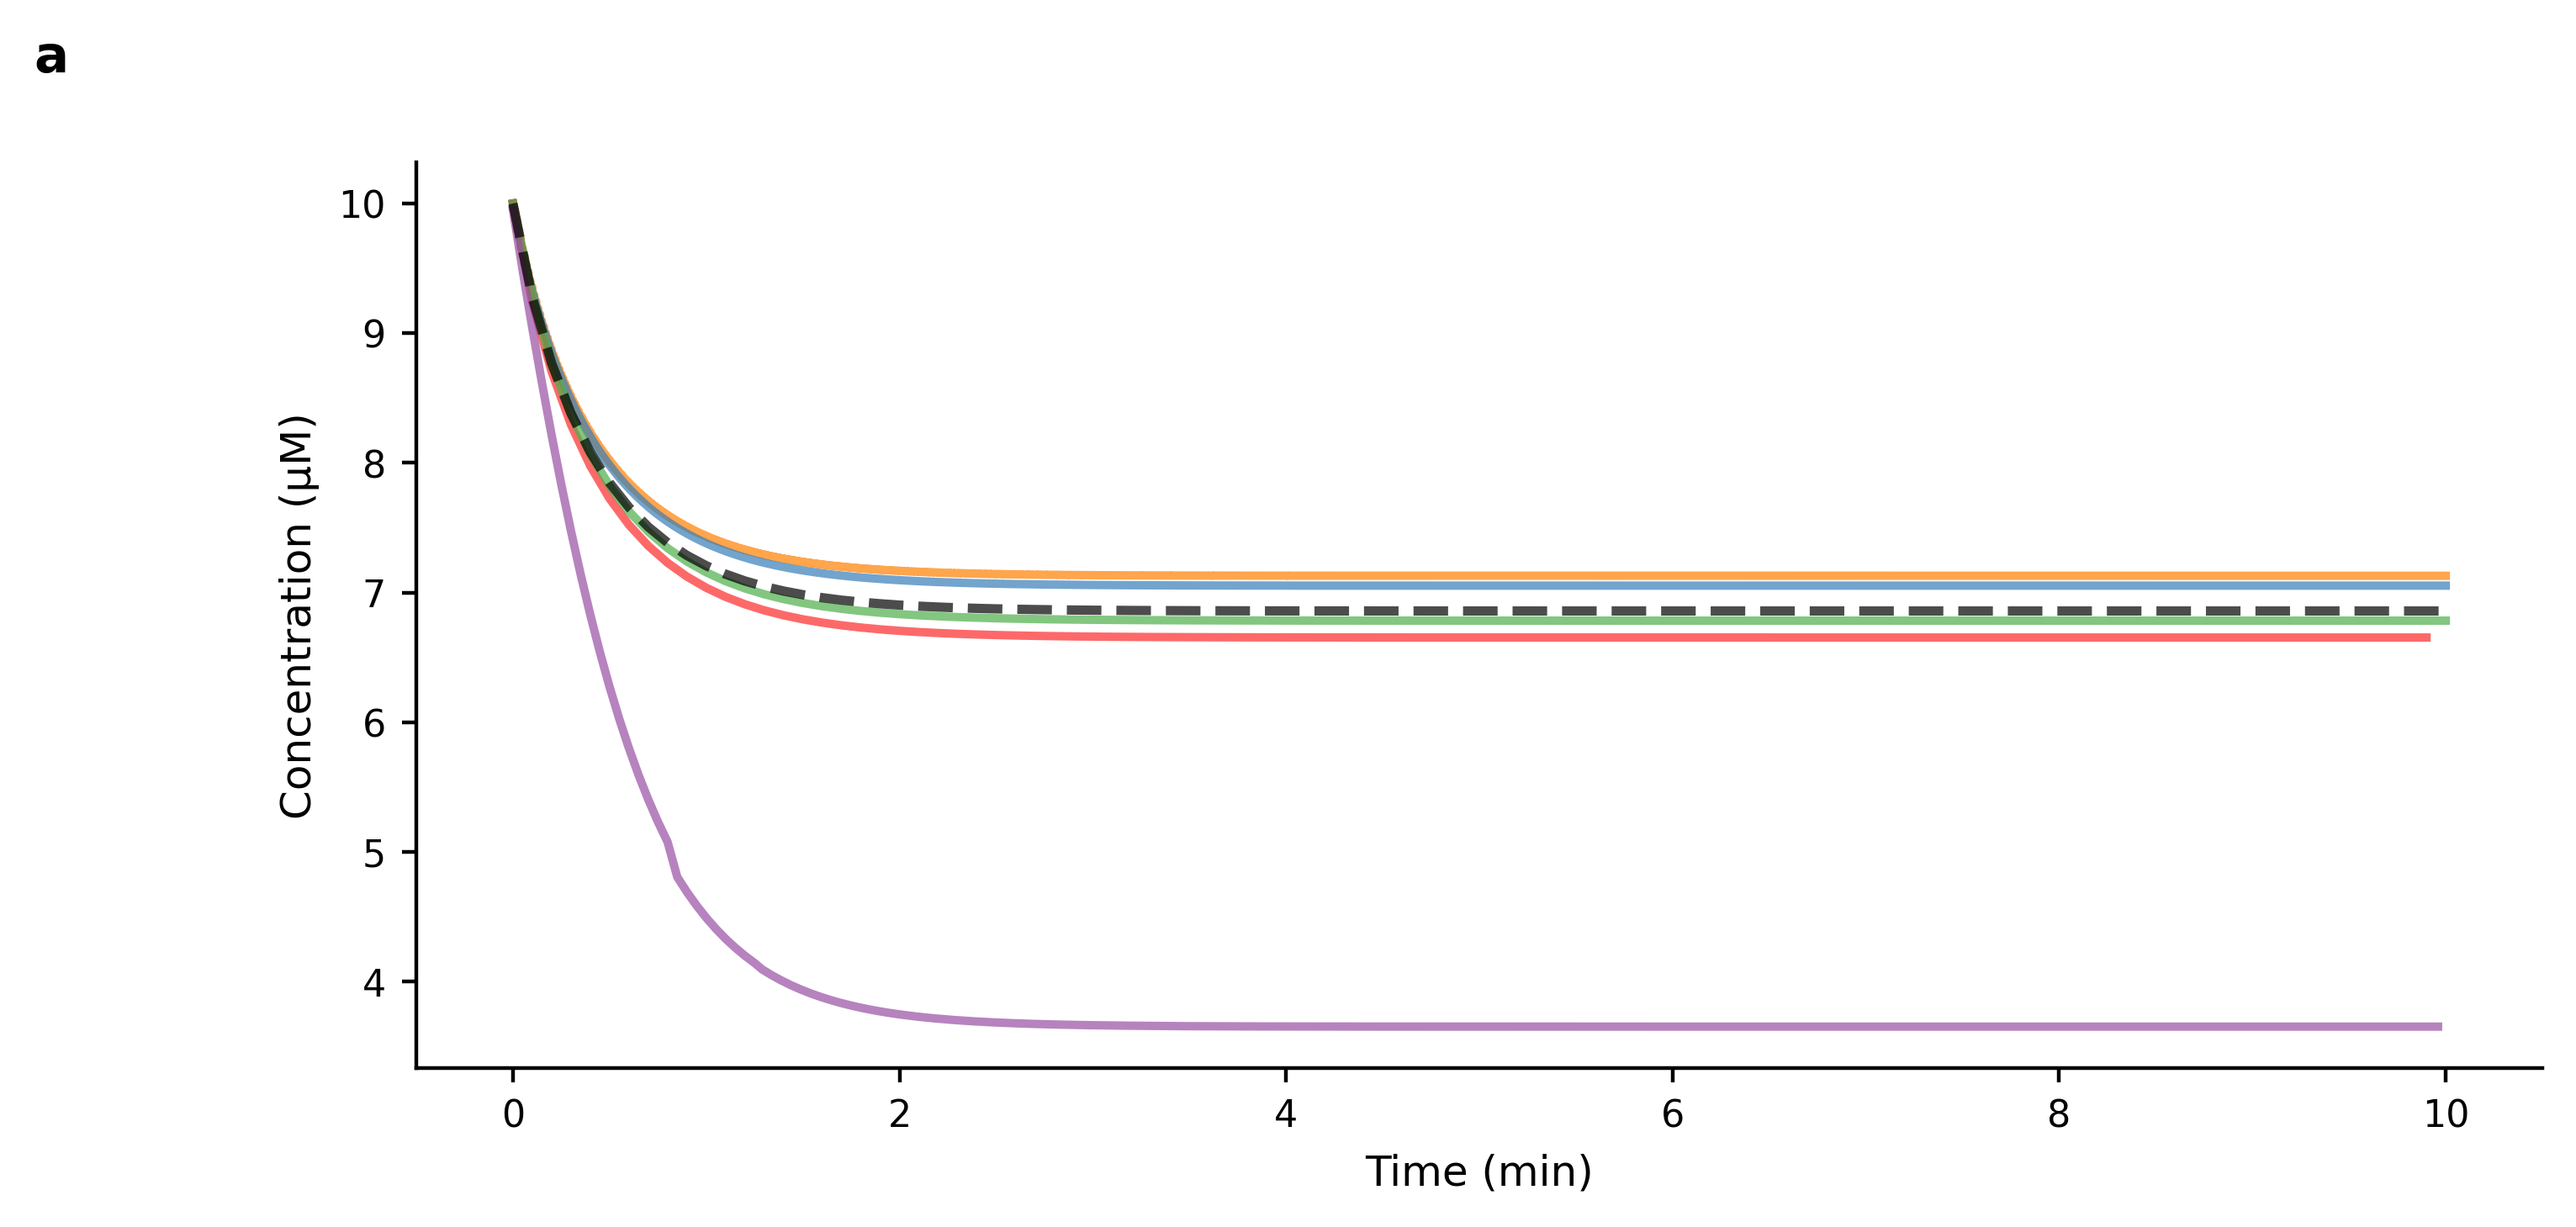

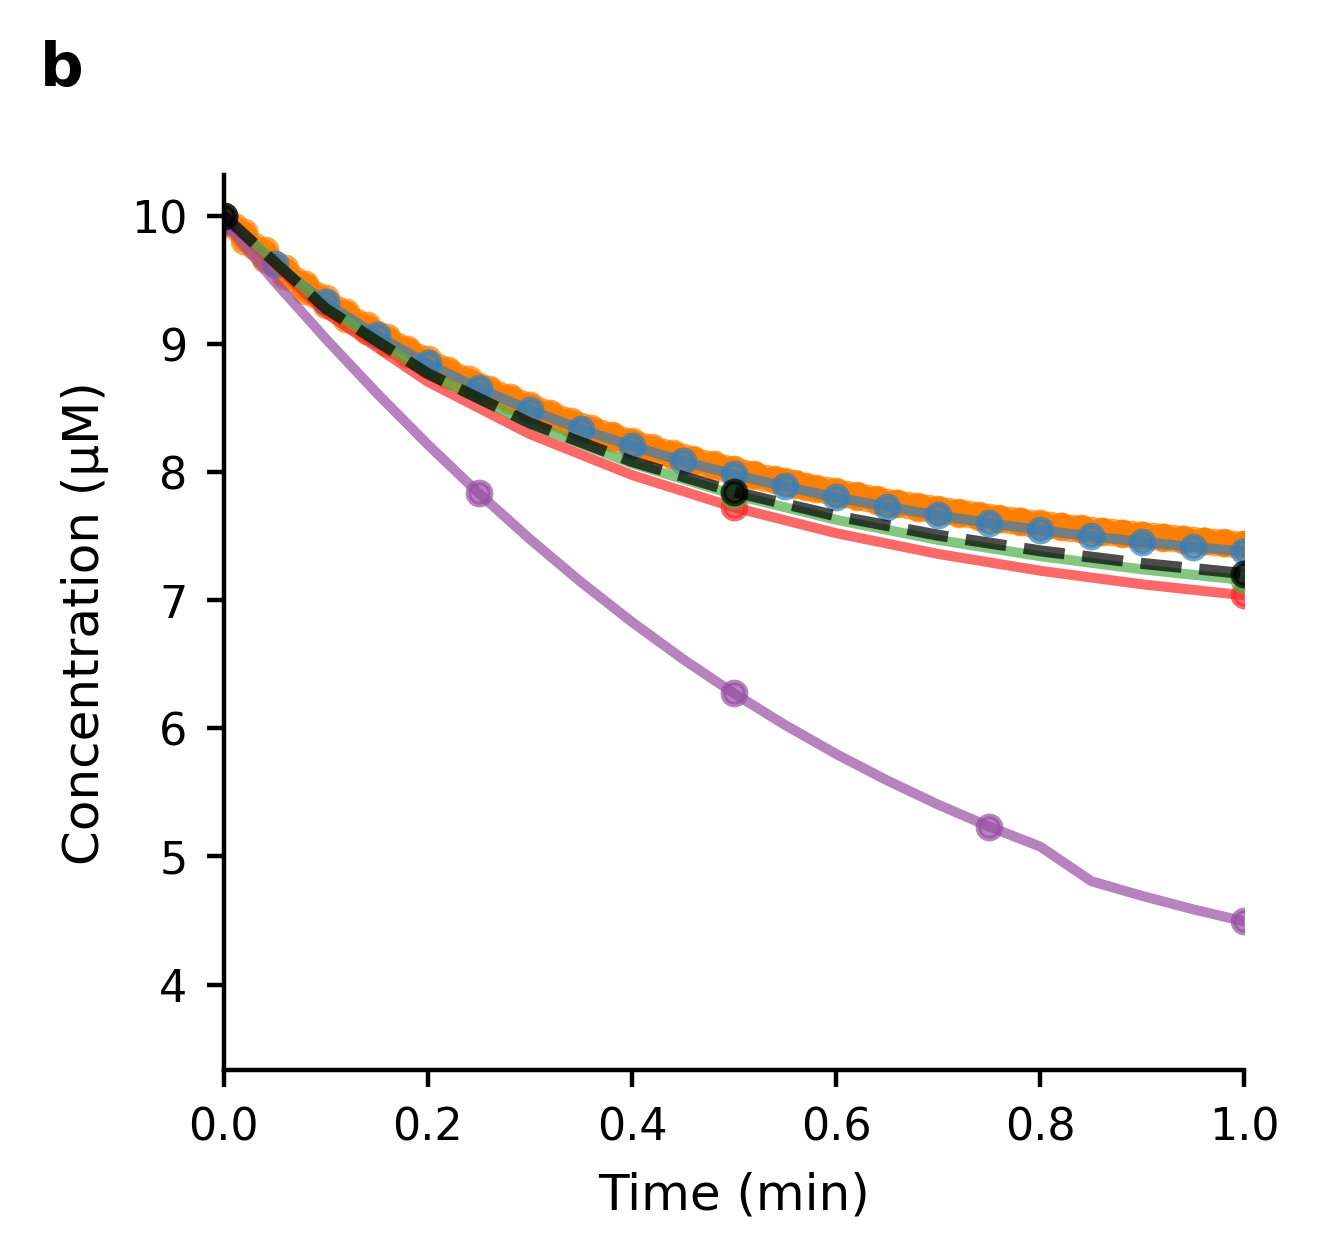

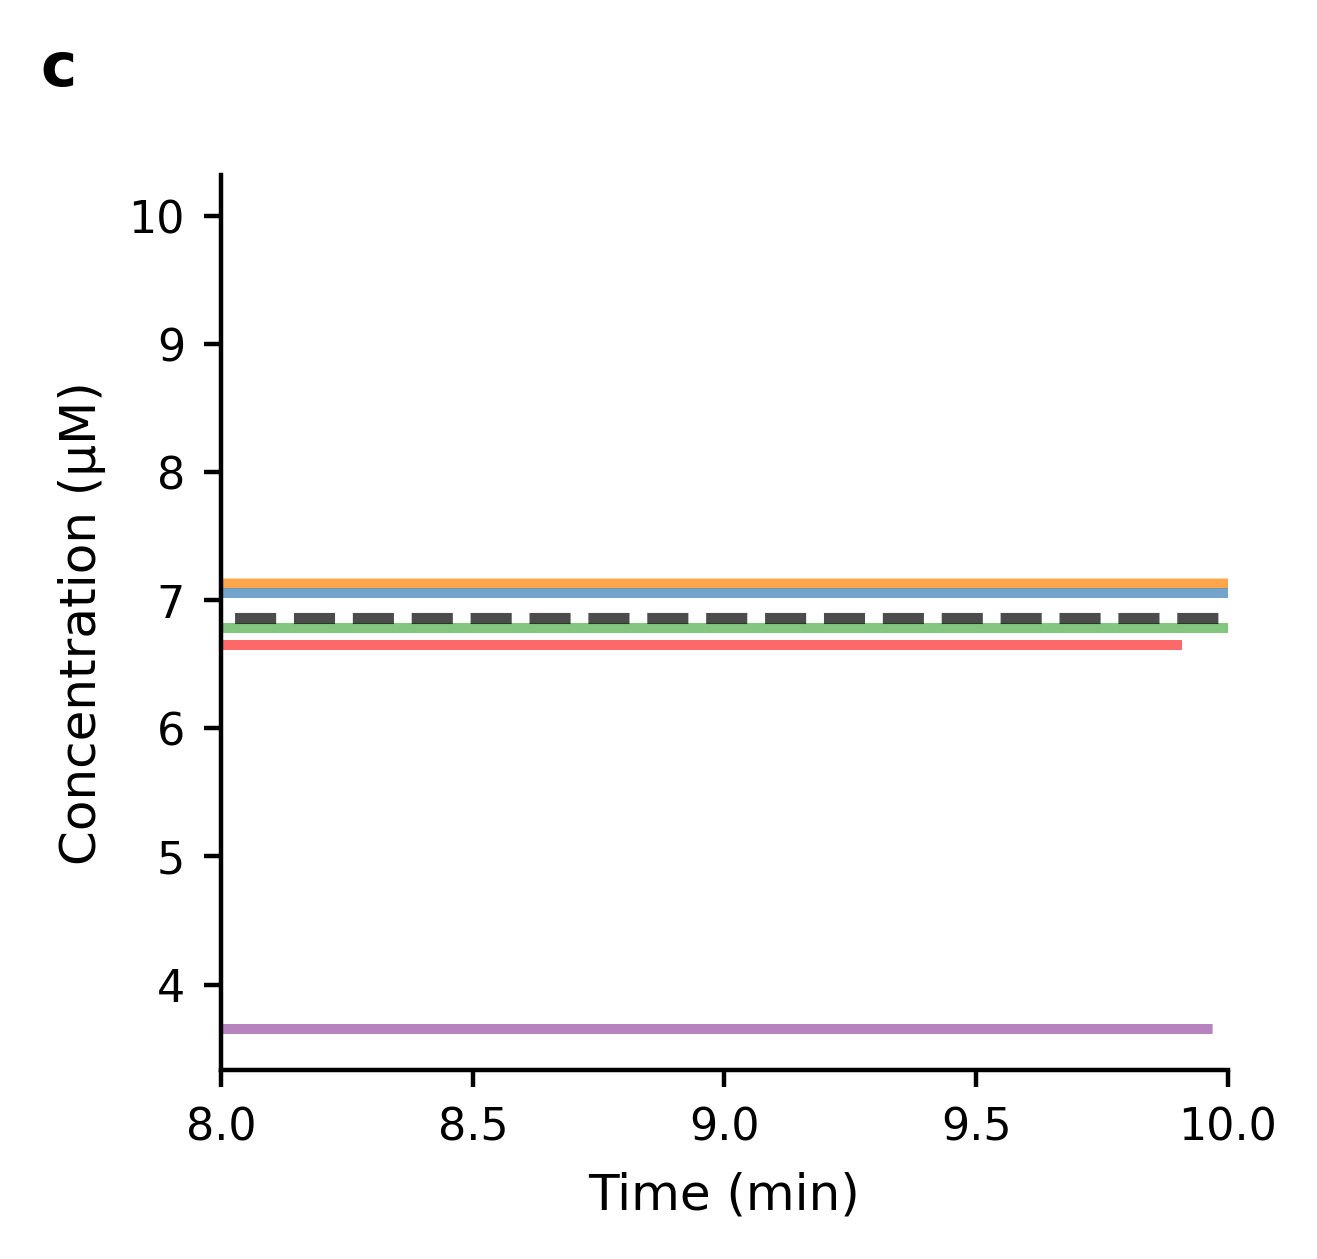

In [15]:
# Panel a: full time course, panel b: early-time zoom (fast decay), panel c: late-time zoom (plateau)
create_nature_plot(_nature_plot_entries(), title='a', filename='decay_full_time', figsize=(7, 3.5))

create_nature_plot(_nature_plot_entries(), xlim=(0, 1), title='b', filename='decay_early_time', markers=True)

create_nature_plot(_nature_plot_entries(), xlim=(8, 10), title='c', filename='decay_late_time', markers=False)


/tmp/ipykernel_64849/3888510550.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.06, 0.06, 1, 0.97])


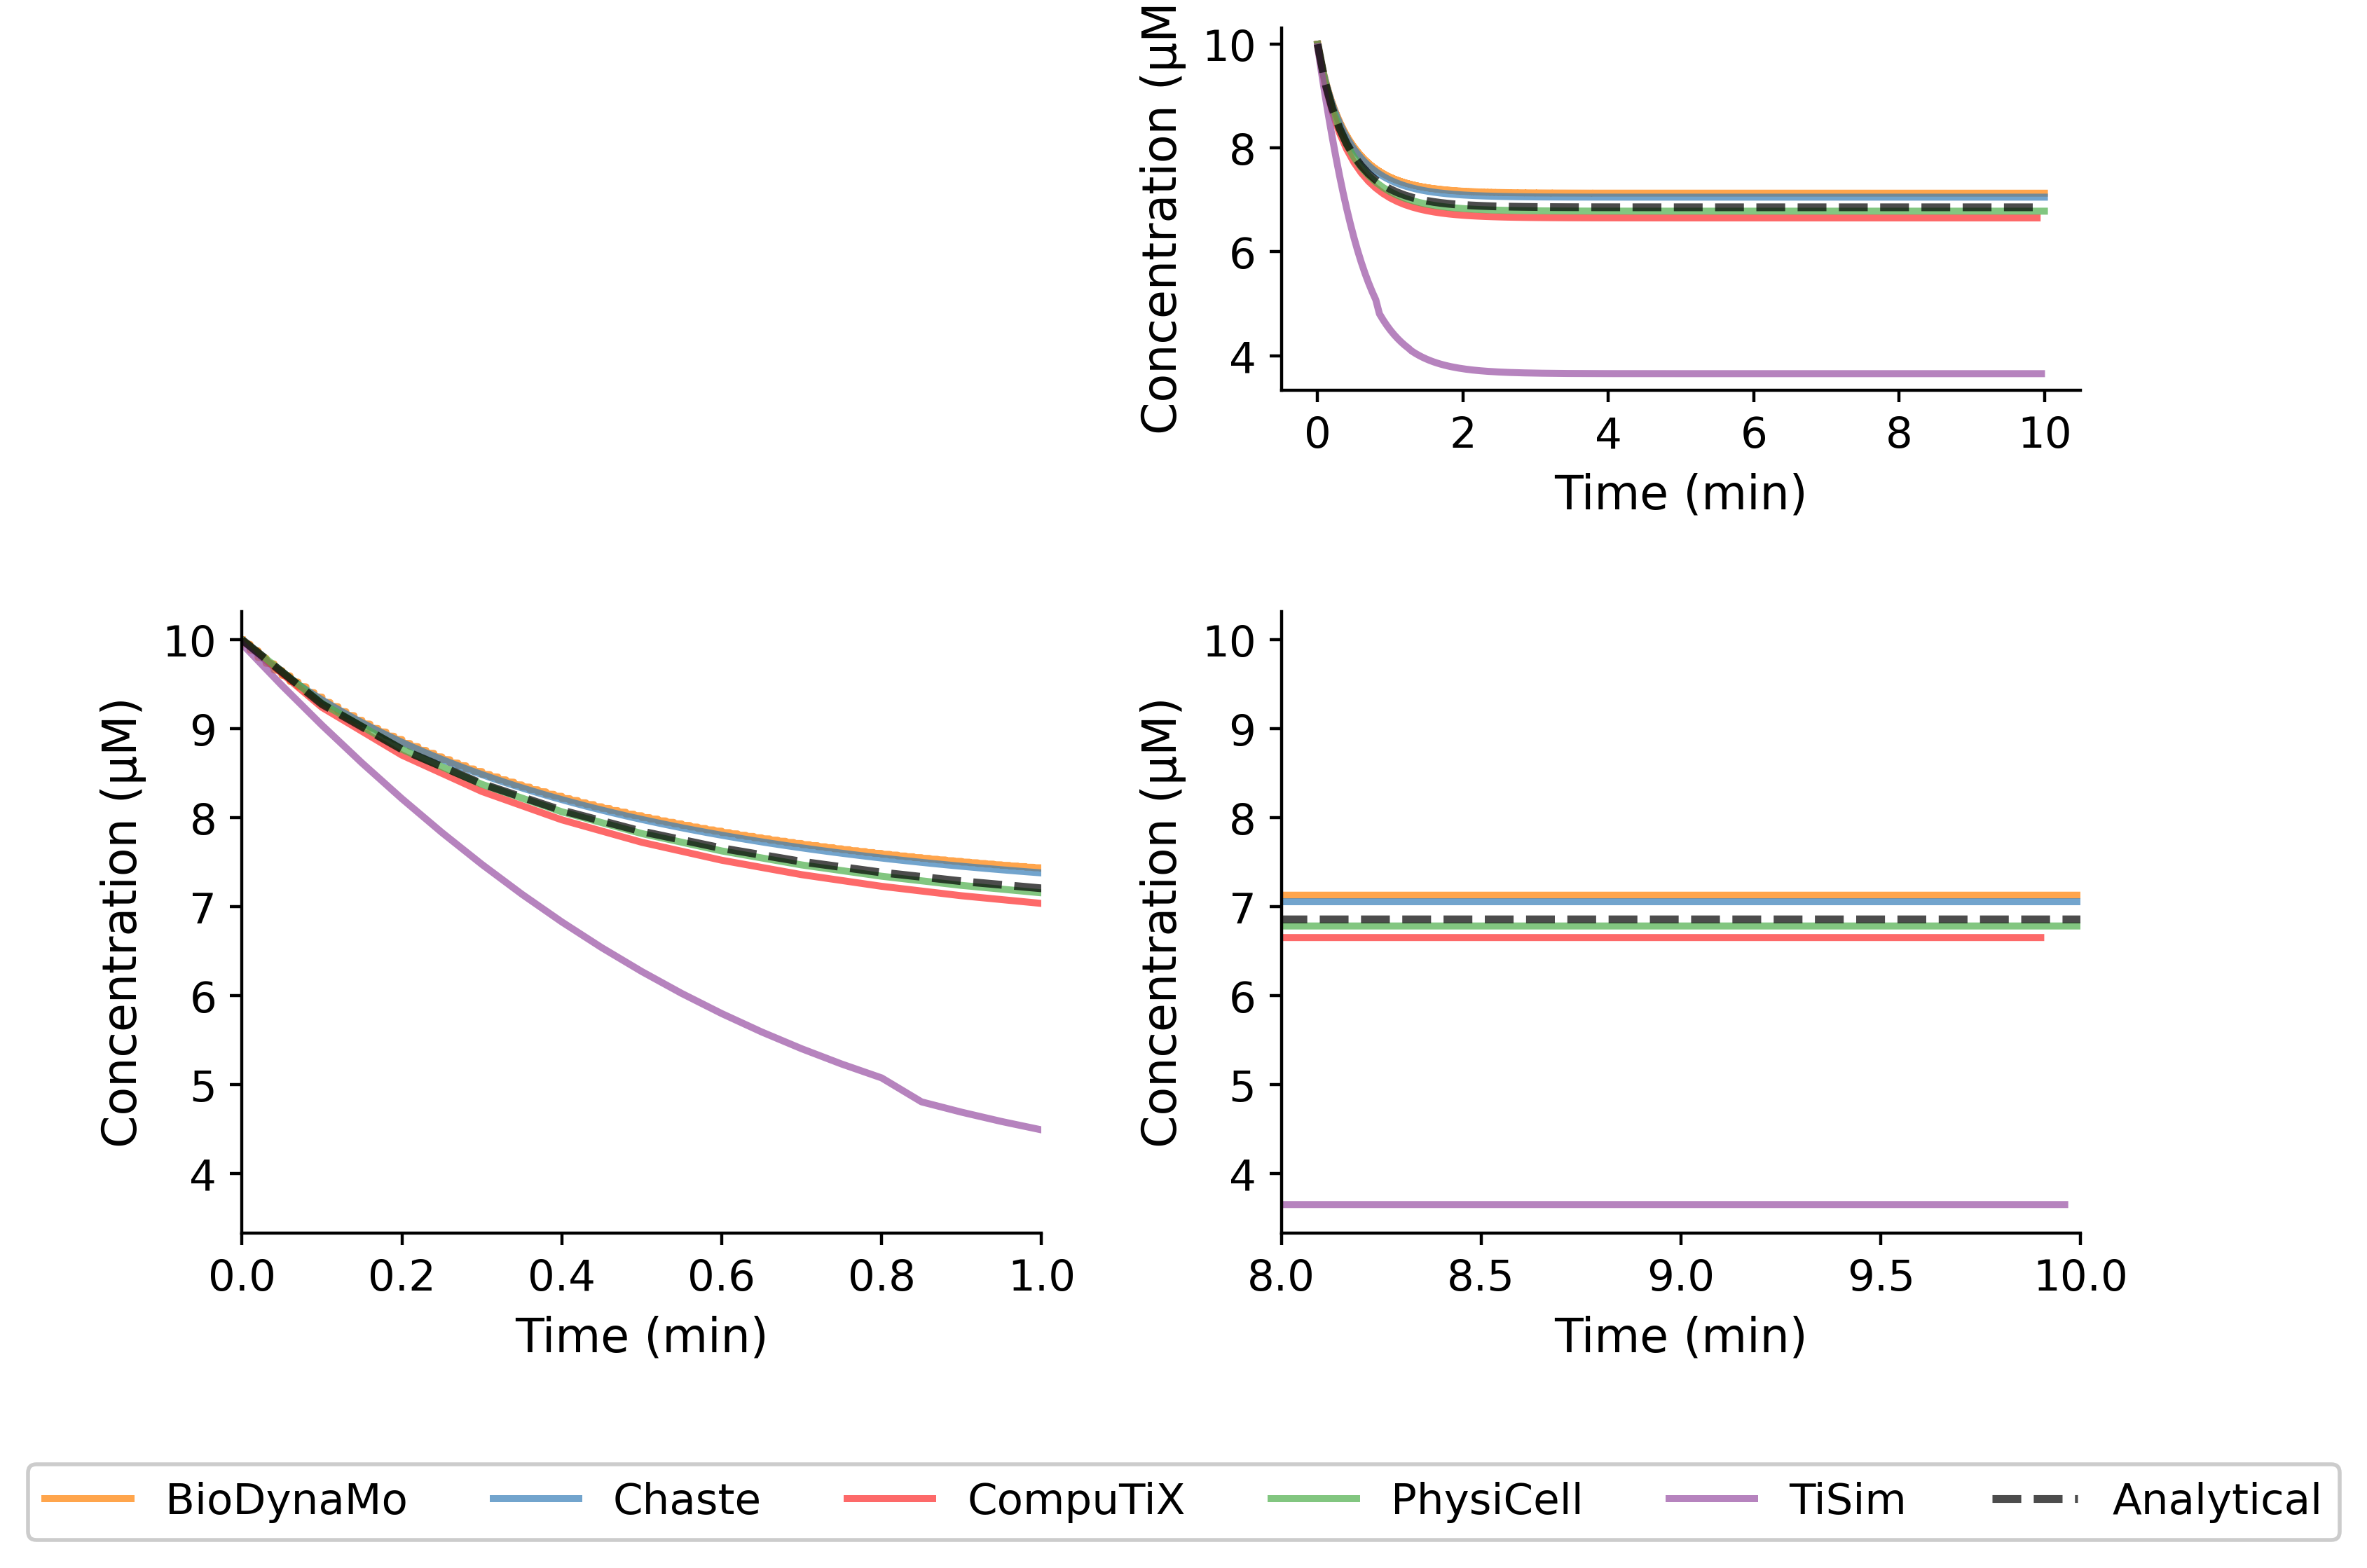

In [16]:
def create_nature_complete_plot():
    fig = plt.figure(figsize=(8, 5))
    gs = gridspec.GridSpec(
        2, 2,
        height_ratios=[0.7, 1.2],
        width_ratios=[1, 1],
        hspace=0.45,
        wspace=0.3,
    )

    entries = _nature_plot_entries()

    # Top left: empty (blank), matches the diffusion_single_paper layout
    ax_empty = fig.add_subplot(gs[0, 0])
    ax_empty.axis('off')

    # Top right: full timecourse
    ax_full = fig.add_subplot(gs[0, 1])
    for label, df, y, mask in entries:
        ax_full.plot(
            df['time_min'][mask], y[mask],
            label=label,
            color=nature_colors[label],
            linestyle=nature_linestyles[label],
            linewidth=nature_linewidths.get(label, 1.8),
            alpha=0.7,
        )
    ax_full.set_ylabel("Concentration (μM)", fontsize=12, labelpad=4)
    ax_full.set_xlabel("Time (min)", fontsize=12, labelpad=4)
    ax_full.tick_params(axis='both', which='major', labelsize=11)
    ax_full.spines['top'].set_visible(False)
    ax_full.spines['right'].set_visible(False)

    # Bottom left: zoom into the early, fast-decay period
    ax_zoom_start = fig.add_subplot(gs[1, 0])
    for label, df, y, mask in entries:
        ax_zoom_start.plot(
            df['time_min'][mask], y[mask],
            label=label,
            color=nature_colors[label],
            linestyle=nature_linestyles[label],
            linewidth=nature_linewidths.get(label, 1.8),
            alpha=0.7,
        )
    ax_zoom_start.set_xlim(0, 1)
    ax_zoom_start.set_xlabel("Time (min)", fontsize=12, labelpad=4)
    ax_zoom_start.set_ylabel("Concentration (μM)", fontsize=12, labelpad=4)
    ax_zoom_start.tick_params(axis='both', which='major', labelsize=11)
    ax_zoom_start.spines['top'].set_visible(False)
    ax_zoom_start.spines['right'].set_visible(False)

    # Bottom right: zoom into the late-time plateau
    ax_zoom_end = fig.add_subplot(gs[1, 1])
    for label, df, y, mask in entries:
        ax_zoom_end.plot(
            df['time_min'][mask], y[mask],
            label=label,
            color=nature_colors[label],
            linestyle=nature_linestyles[label],
            linewidth=nature_linewidths.get(label, 1.8),
            alpha=0.7,
        )
    ax_zoom_end.set_xlim(8, 10)
    ax_zoom_end.set_xlabel("Time (min)", fontsize=12, labelpad=4)
    ax_zoom_end.set_ylabel("Concentration (μM)", fontsize=12, labelpad=4)
    ax_zoom_end.tick_params(axis='both', which='major', labelsize=11)
    ax_zoom_end.spines['top'].set_visible(False)
    ax_zoom_end.spines['right'].set_visible(False)

    # Shared legend (move above the plots)
    handles, labels = ax_full.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.04),
        ncol=8,
        frameon=True,
        framealpha=1.0,
        fontsize=11,
    )

    plt.tight_layout(rect=[0.06, 0.06, 1, 0.97])
    plt.subplots_adjust(left=0.08, top=0.97, hspace=0.45, wspace=0.3)

    fig.savefig(nature_plot_dir / "decay_nature_style_combined.svg", format='svg', bbox_inches='tight', pad_inches=0.2)
    fig.savefig(nature_plot_dir / "decay_nature_style_combined.png", format='png', bbox_inches='tight', pad_inches=0.2, dpi=600)
    plt.show()
    plt.close(fig)


create_nature_complete_plot()
